In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
})

In [2]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")
options(repr.plot.width = 20, repr.plot.height = 10)

In [3]:
meta = read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/wildtype_injection/chimera-wt/meta.csv")
meta = meta %>% filter(celltype.mapped != 'Doublet' & celltype.mapped != 'Stripped')

out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
own_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
own_meta <- own_meta %>% filter(!is.na(own_meta$tdTom))

In [6]:
nrow(own_meta)

[1] 37208

In [9]:
unique(meta$sample)

[1] 1 2 3 4 5 6

In [128]:
pdf3 = table(meta$celltype.mapped, meta$tomato)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [129]:
pdf3 = table(own_meta$celltype.mapped, own_meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p2 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

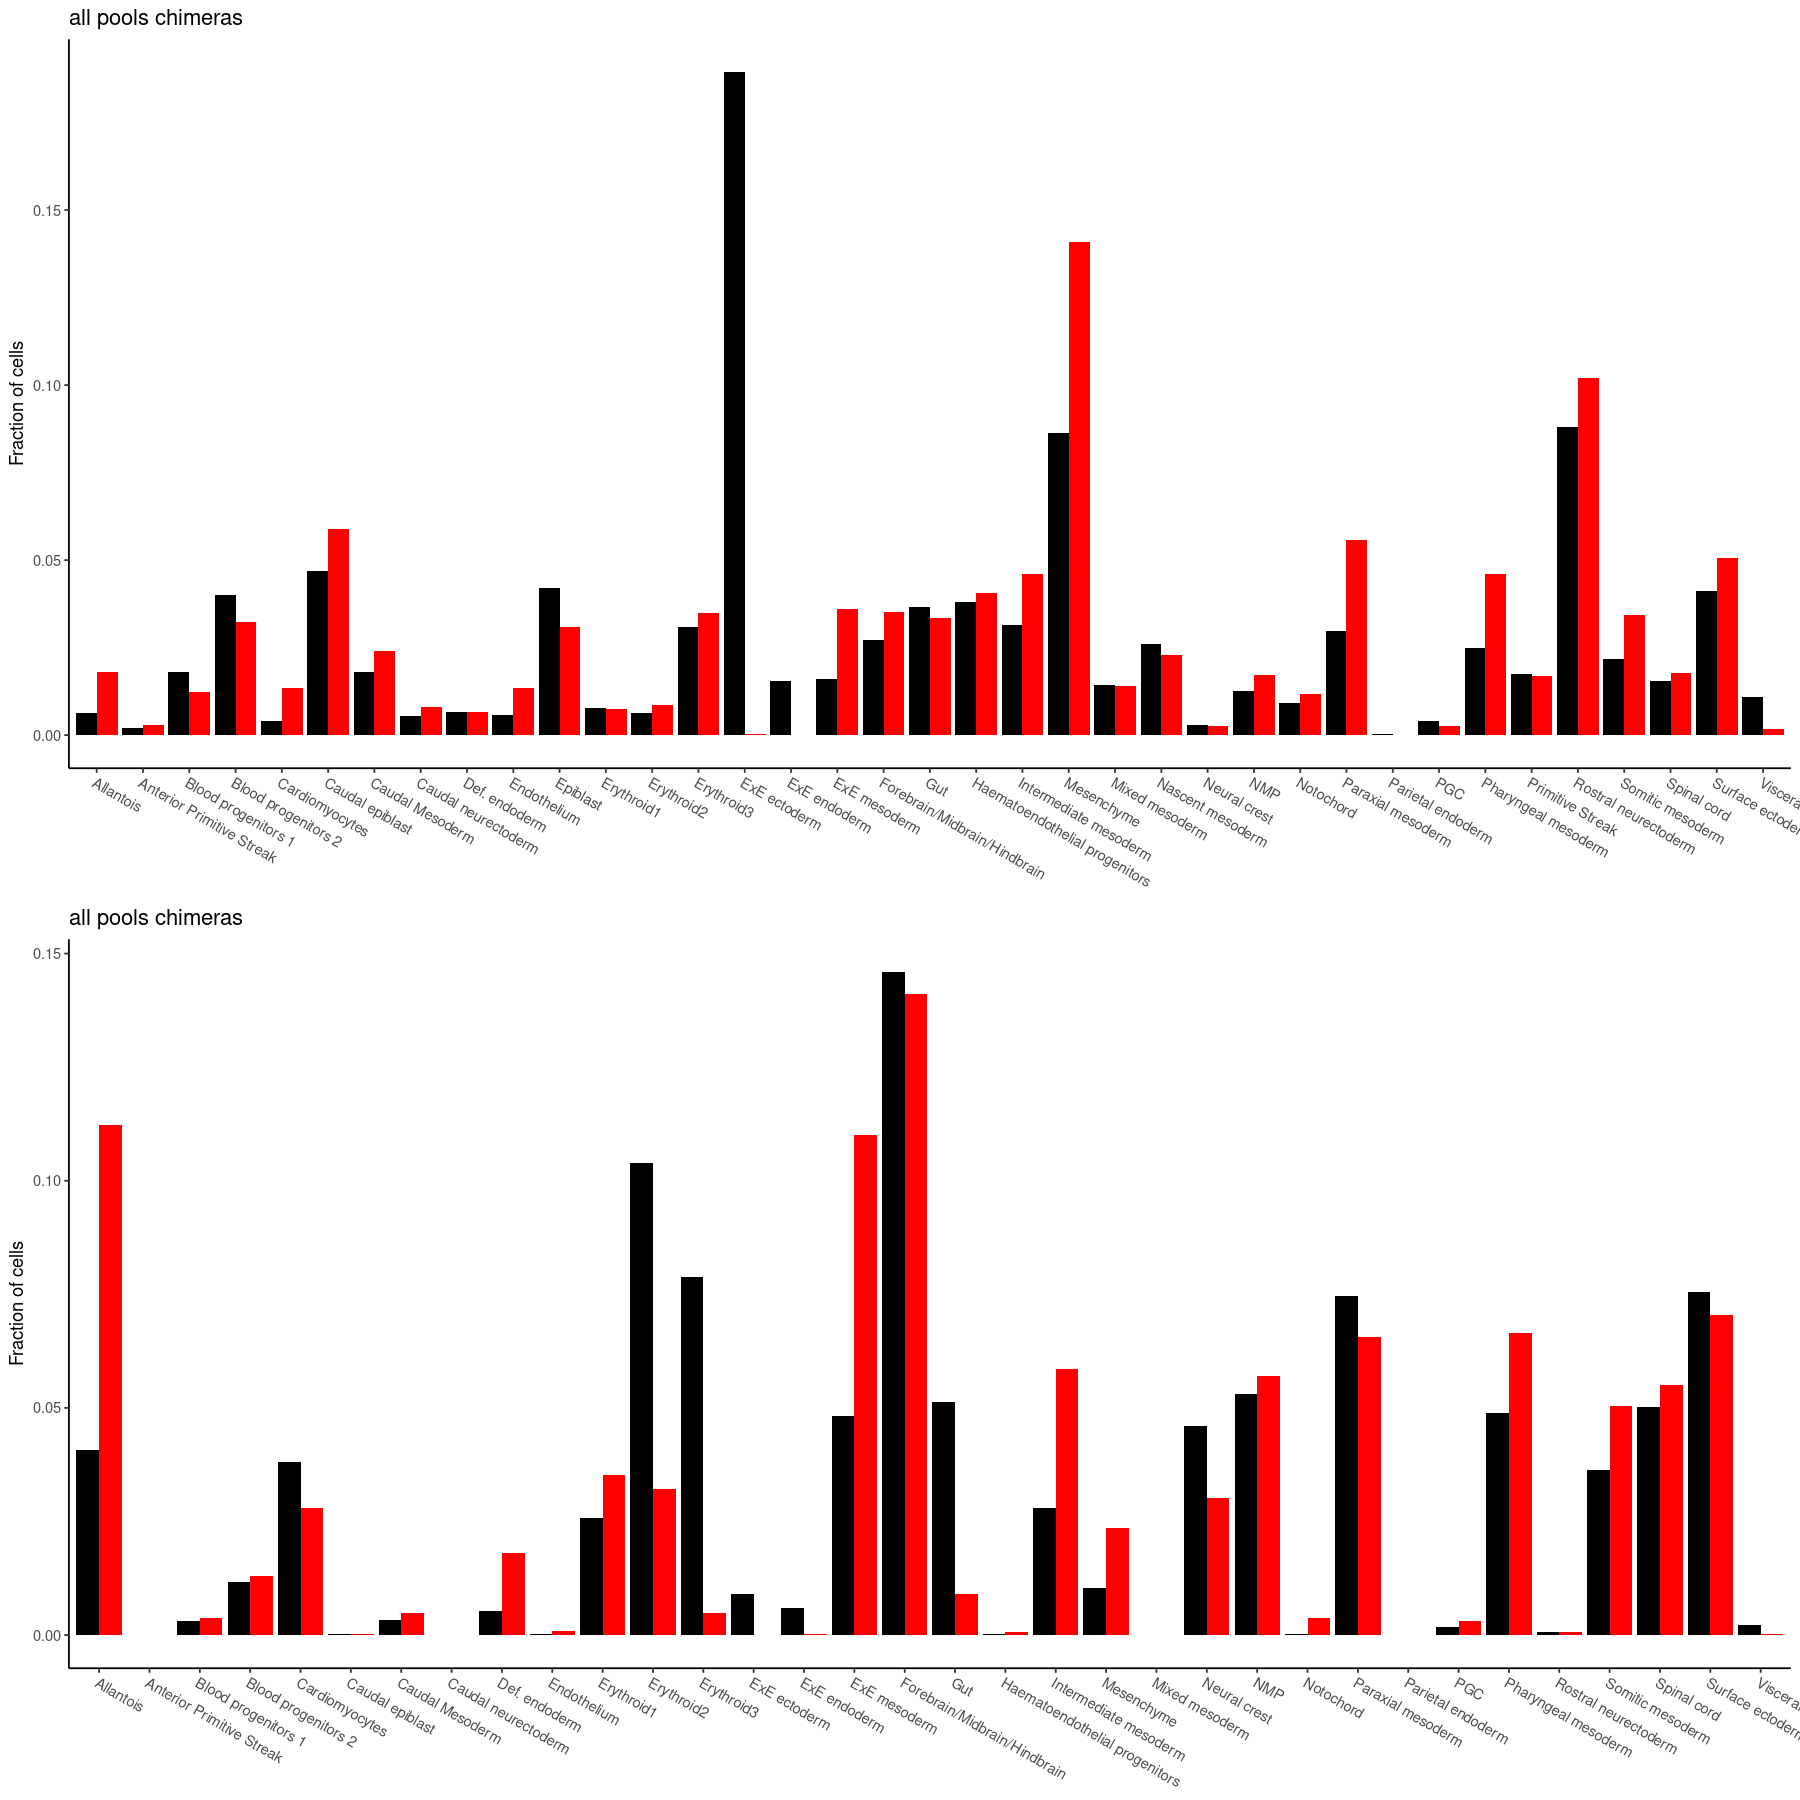

In [130]:
options(repr.plot.width = 15, repr.plot.height = 15)
grid.arrange(p1, p2, nrow =2)

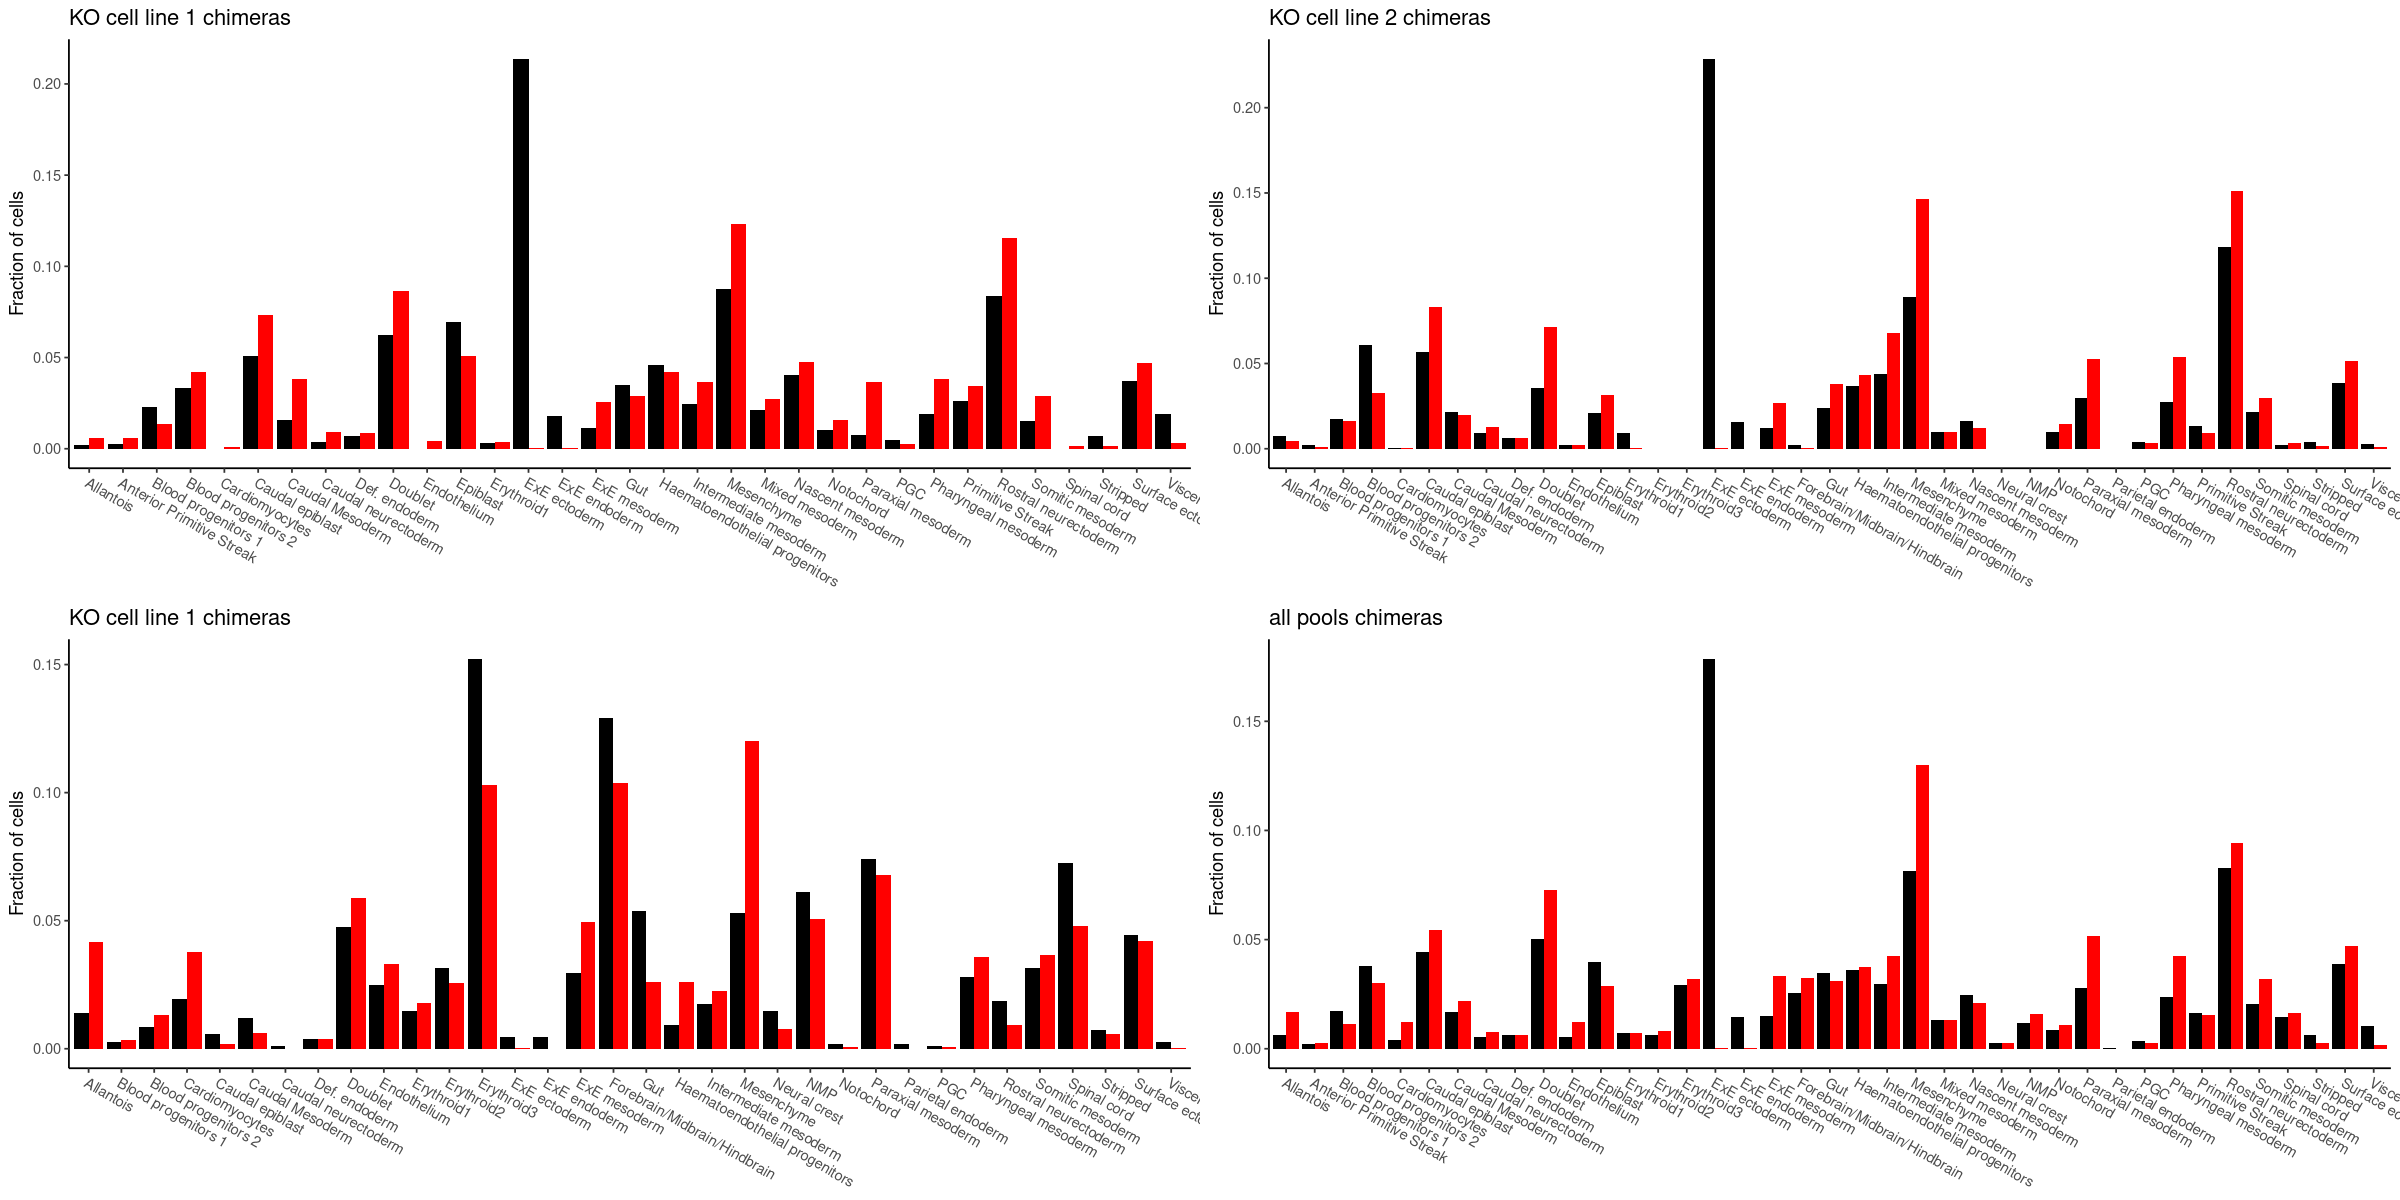

In [37]:
embryo1 <- c('1', '2') # not actually embryo but KO cell line pool
embryo2 <- c('3', '4')
embryo3 <- c('5', '6')

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tomato[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])


pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tomato[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p2 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))], 
                   drop = FALSE)

pdf4 = table(meta$celltype.mapped[meta$sample %in% embryo3], meta$tomato[meta$sample %in% embryo3])
pdf4 = as.data.frame(sweep(pdf4, 2, colSums(pdf4), "/"))

p3 = ggplot(data = pdf4, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

pdf3 = table(meta$celltype.mapped, meta$tomato)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

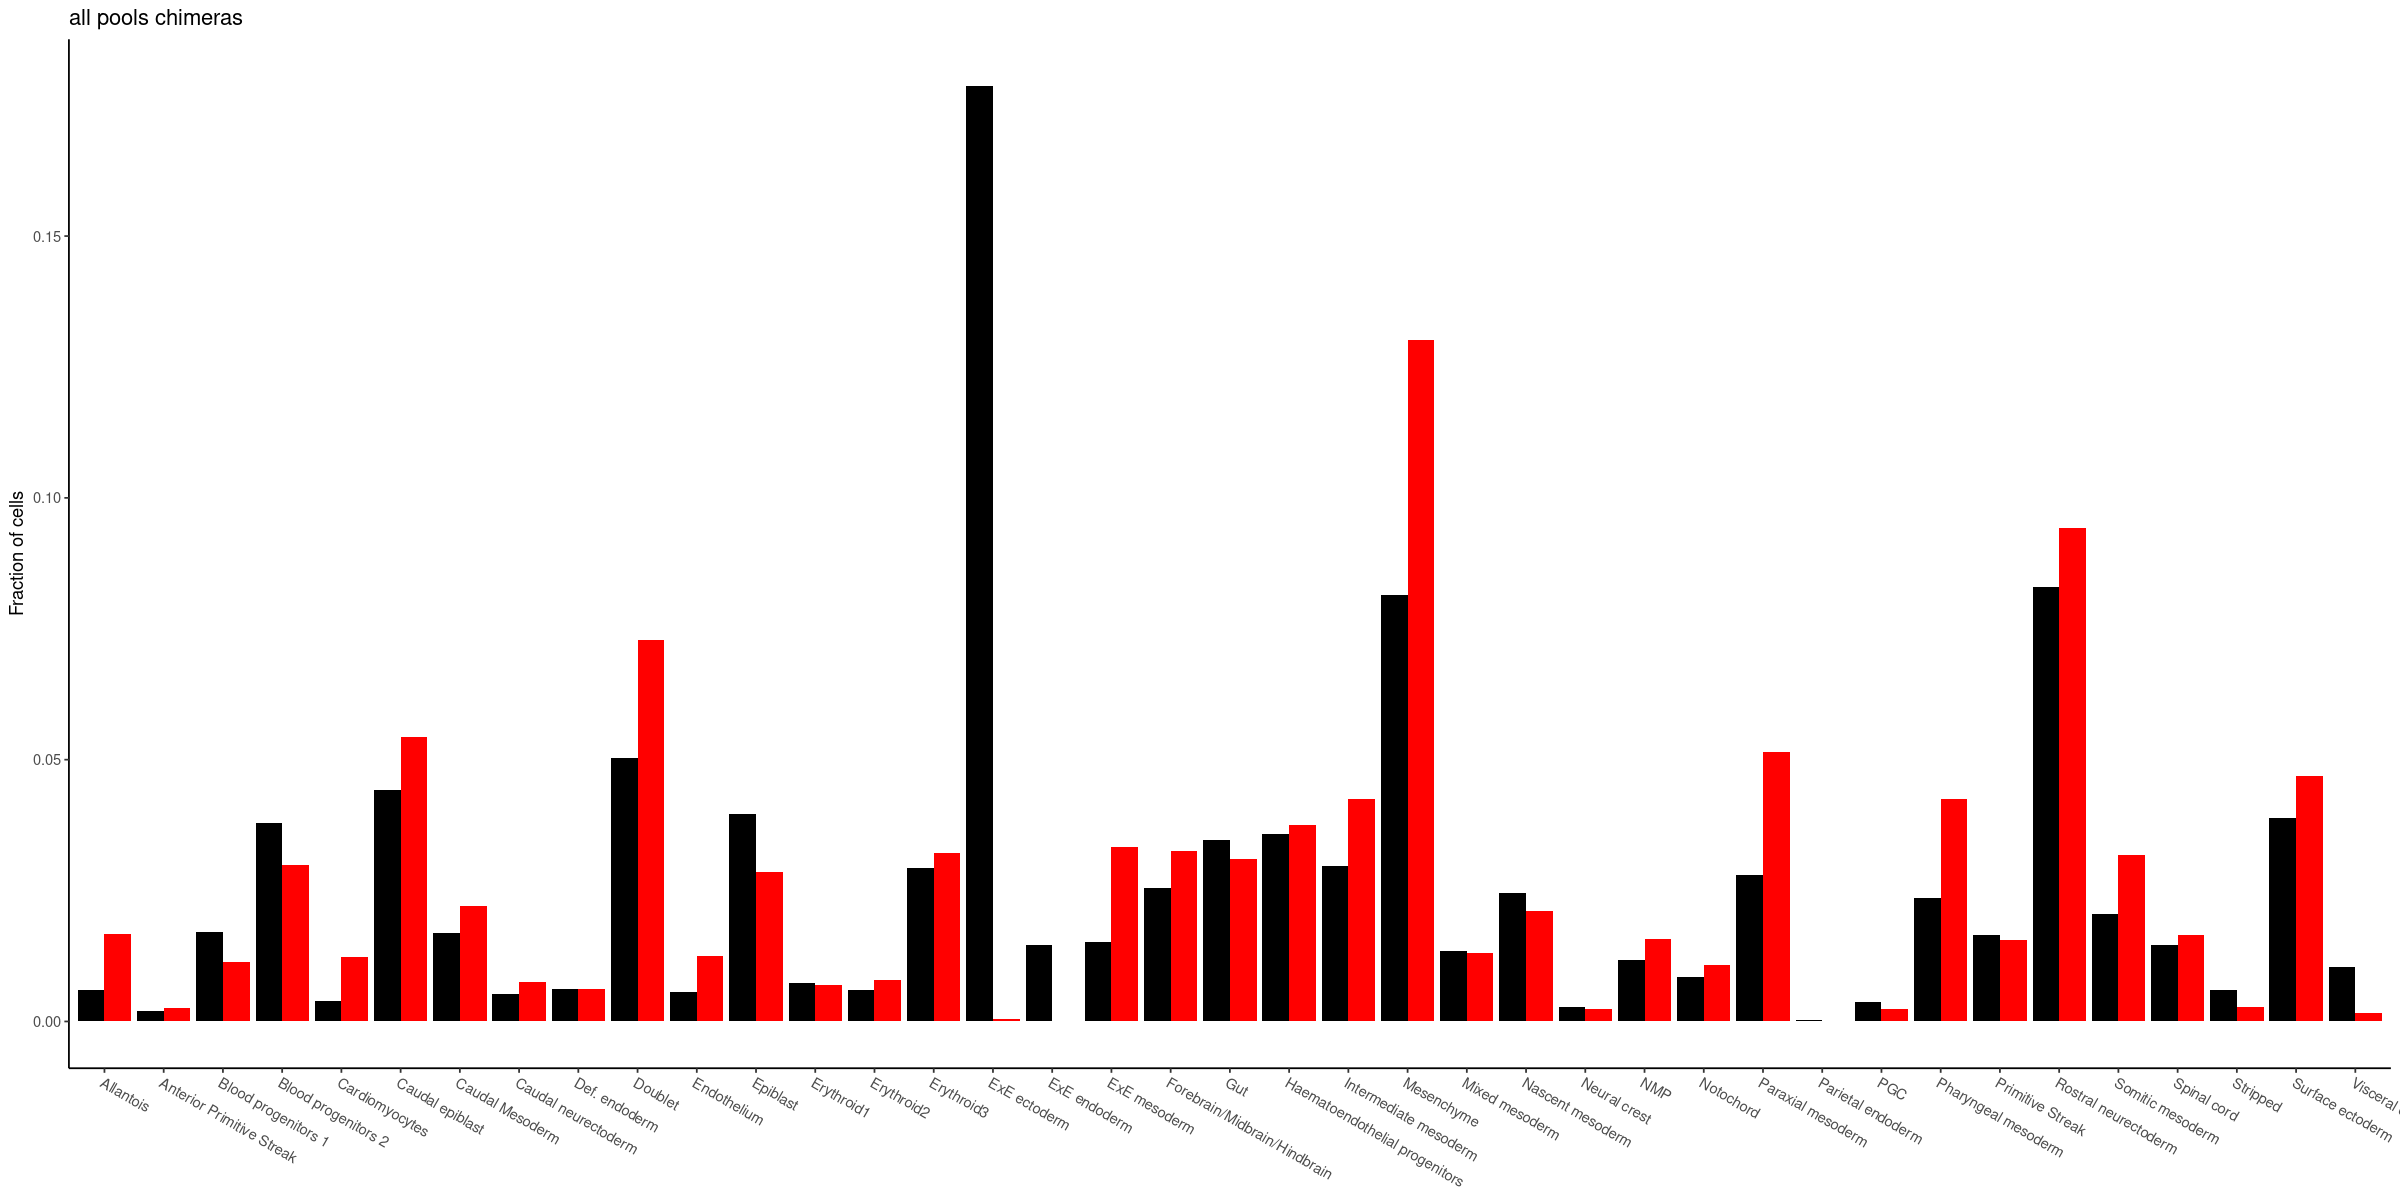

In [38]:
p4

In [74]:
colnames(pdf1) = c('Var1','Var2', 'Freq_1')
colnames(pdf2) = c('Var1','Var2', 'Freq_2')
colnames(pdf3) = c('Var1','Var2', 'Freq_3')
merged = merge(pdf1, pdf2, by=c('Var1', 'Var2'), all=TRUE)
merged = merge(merged, pdf3, by=c('Var1', 'Var2'), all=TRUE)


In [81]:
unique(merged$Var1)

[1] Allantois                      Anterior Primitive Streak     
 [3] Blood progenitors 1            Blood progenitors 2           
 [5] Cardiomyocytes                 Caudal epiblast               
 [7] Caudal Mesoderm                Caudal neurectoderm           
 [9] Def. endoderm                  Doublet                       
[11] Endothelium                    Epiblast                      
[13] Erythroid1                     ExE ectoderm                  
[15] ExE endoderm                   ExE mesoderm                  
[17] Gut                            Haematoendothelial progenitors
[19] Intermediate mesoderm          Mesenchyme                    
[21] Mixed mesoderm                 Nascent mesoderm              
[23] Notochord                      Paraxial mesoderm             
[25] PGC                            Pharyngeal mesoderm           
[27] Primitive Streak               Rostral neurectoderm          
[29] Somitic mesoderm               Spinal cord                   
[31] Stripped                       Surface ectoderm              
[33] Visceral endoderm              Forebrain/Midbrain/Hindbrain  
[35] Erythroid2                     Erythroid3                    
[37] Neural crest                   NMP                           
[39] Parietal endoderm             
39 Levels: Allantois Anterior Primitive Streak ... Parietal endoderm

In [75]:
test = gather(merged, sample, frequency, Freq_1:Freq_3)

In [76]:
test2 = test %>% group_by(Var1, Var2) %>% summarize(mean = mean(frequency, na.rm=TRUE), sd = sd(frequency, na.rm=TRUE))

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)



In [94]:
test2$Var1 = factor(test2$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])  

In [95]:
p4 = ggplot(data = test2, mapping = aes(x = Var1, y = mean, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

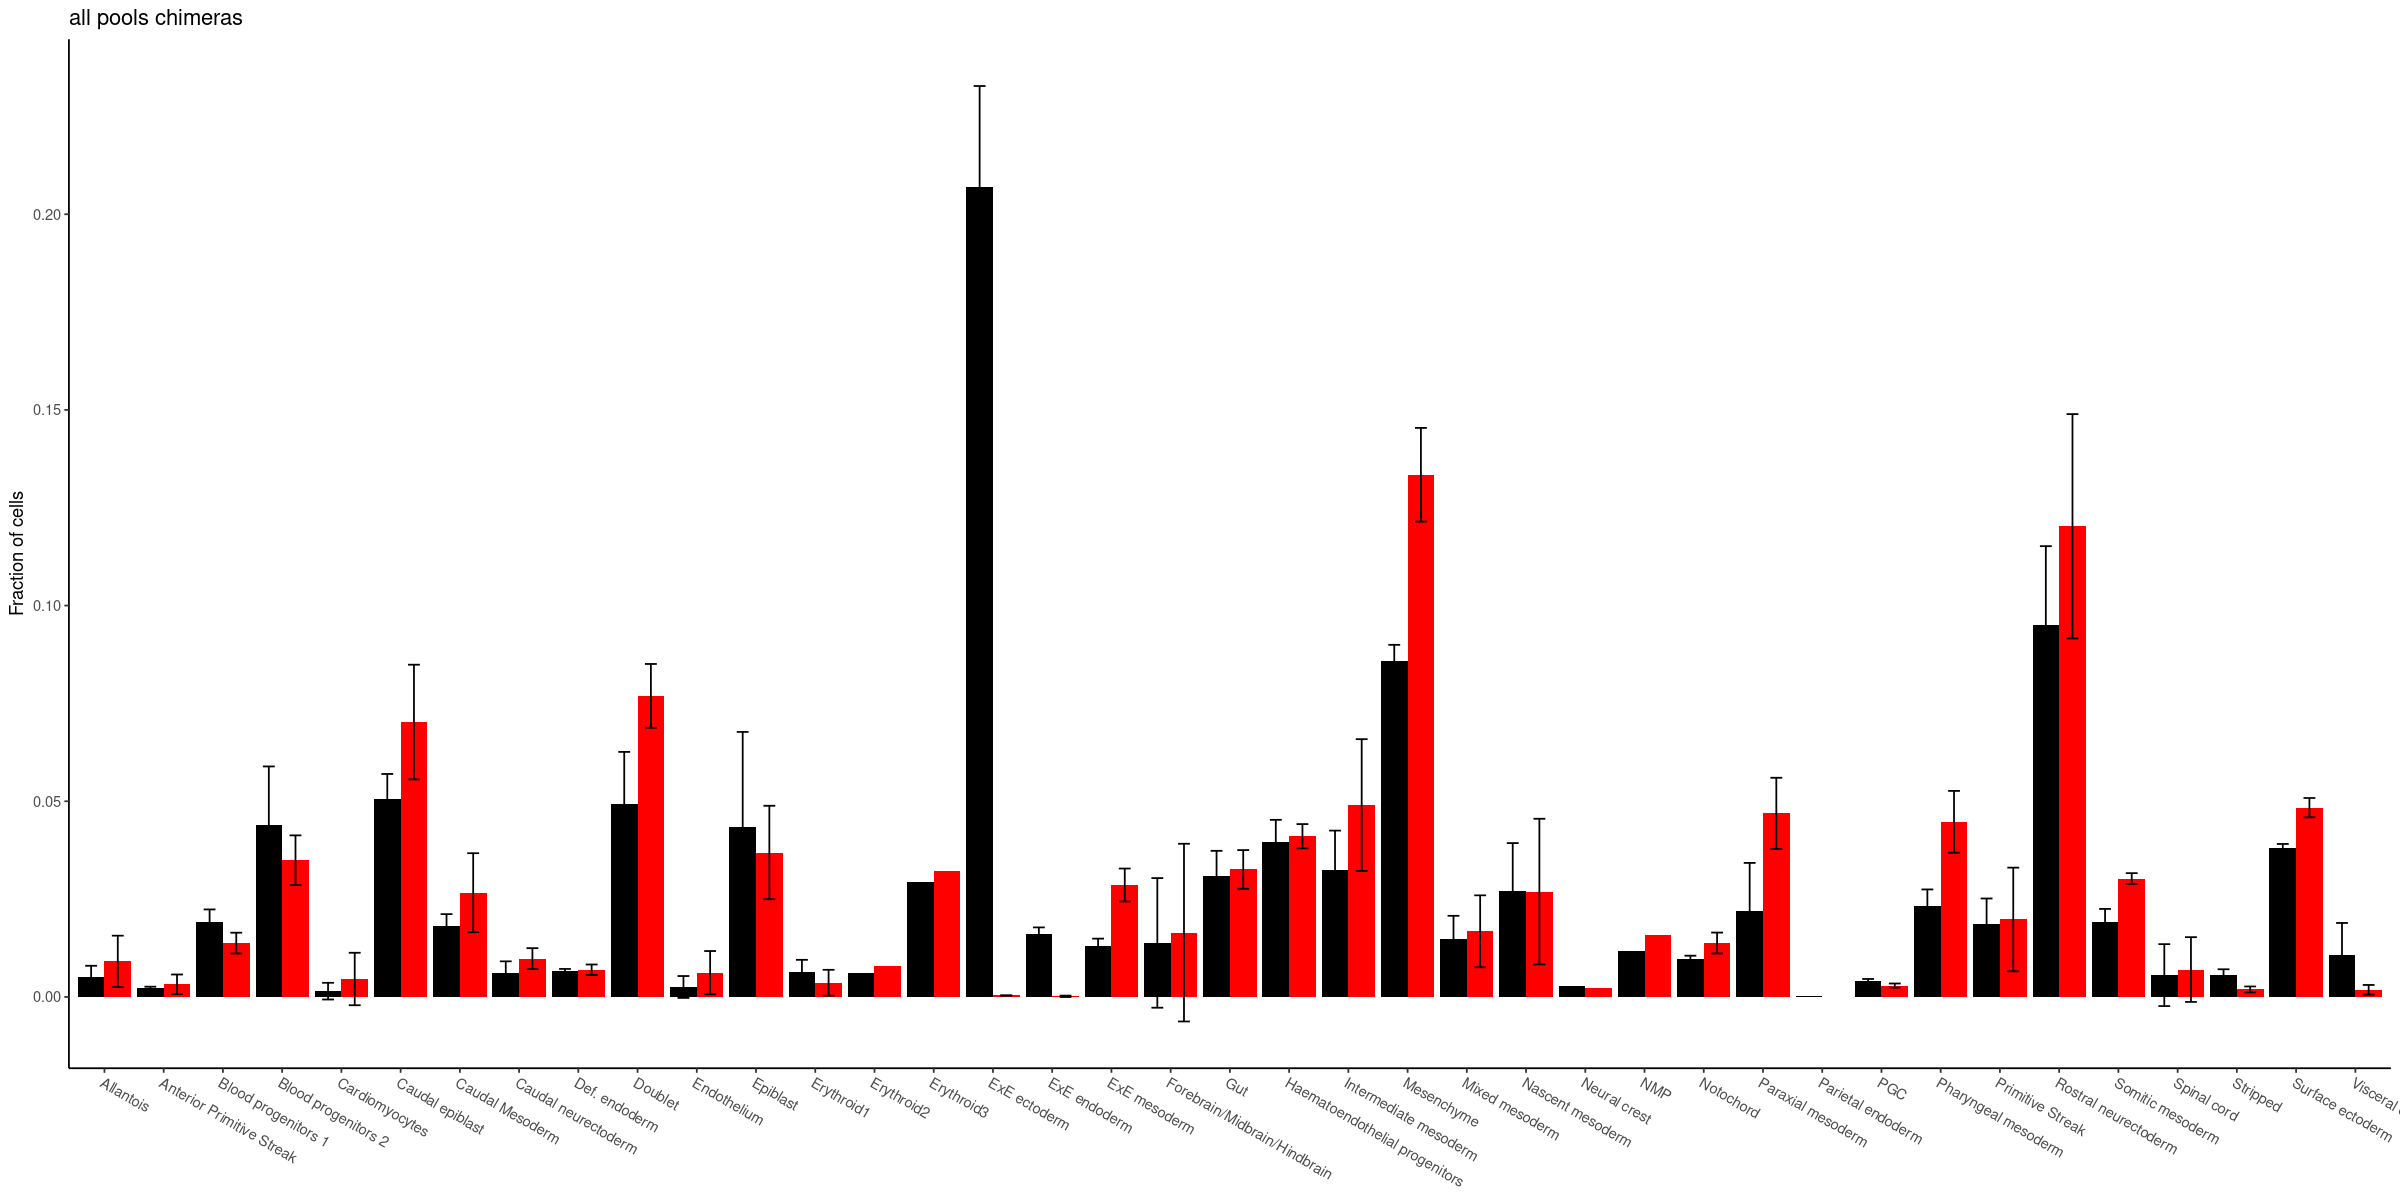

In [96]:
p4

`summarise()` ungrouping output (override with `.groups` argument)



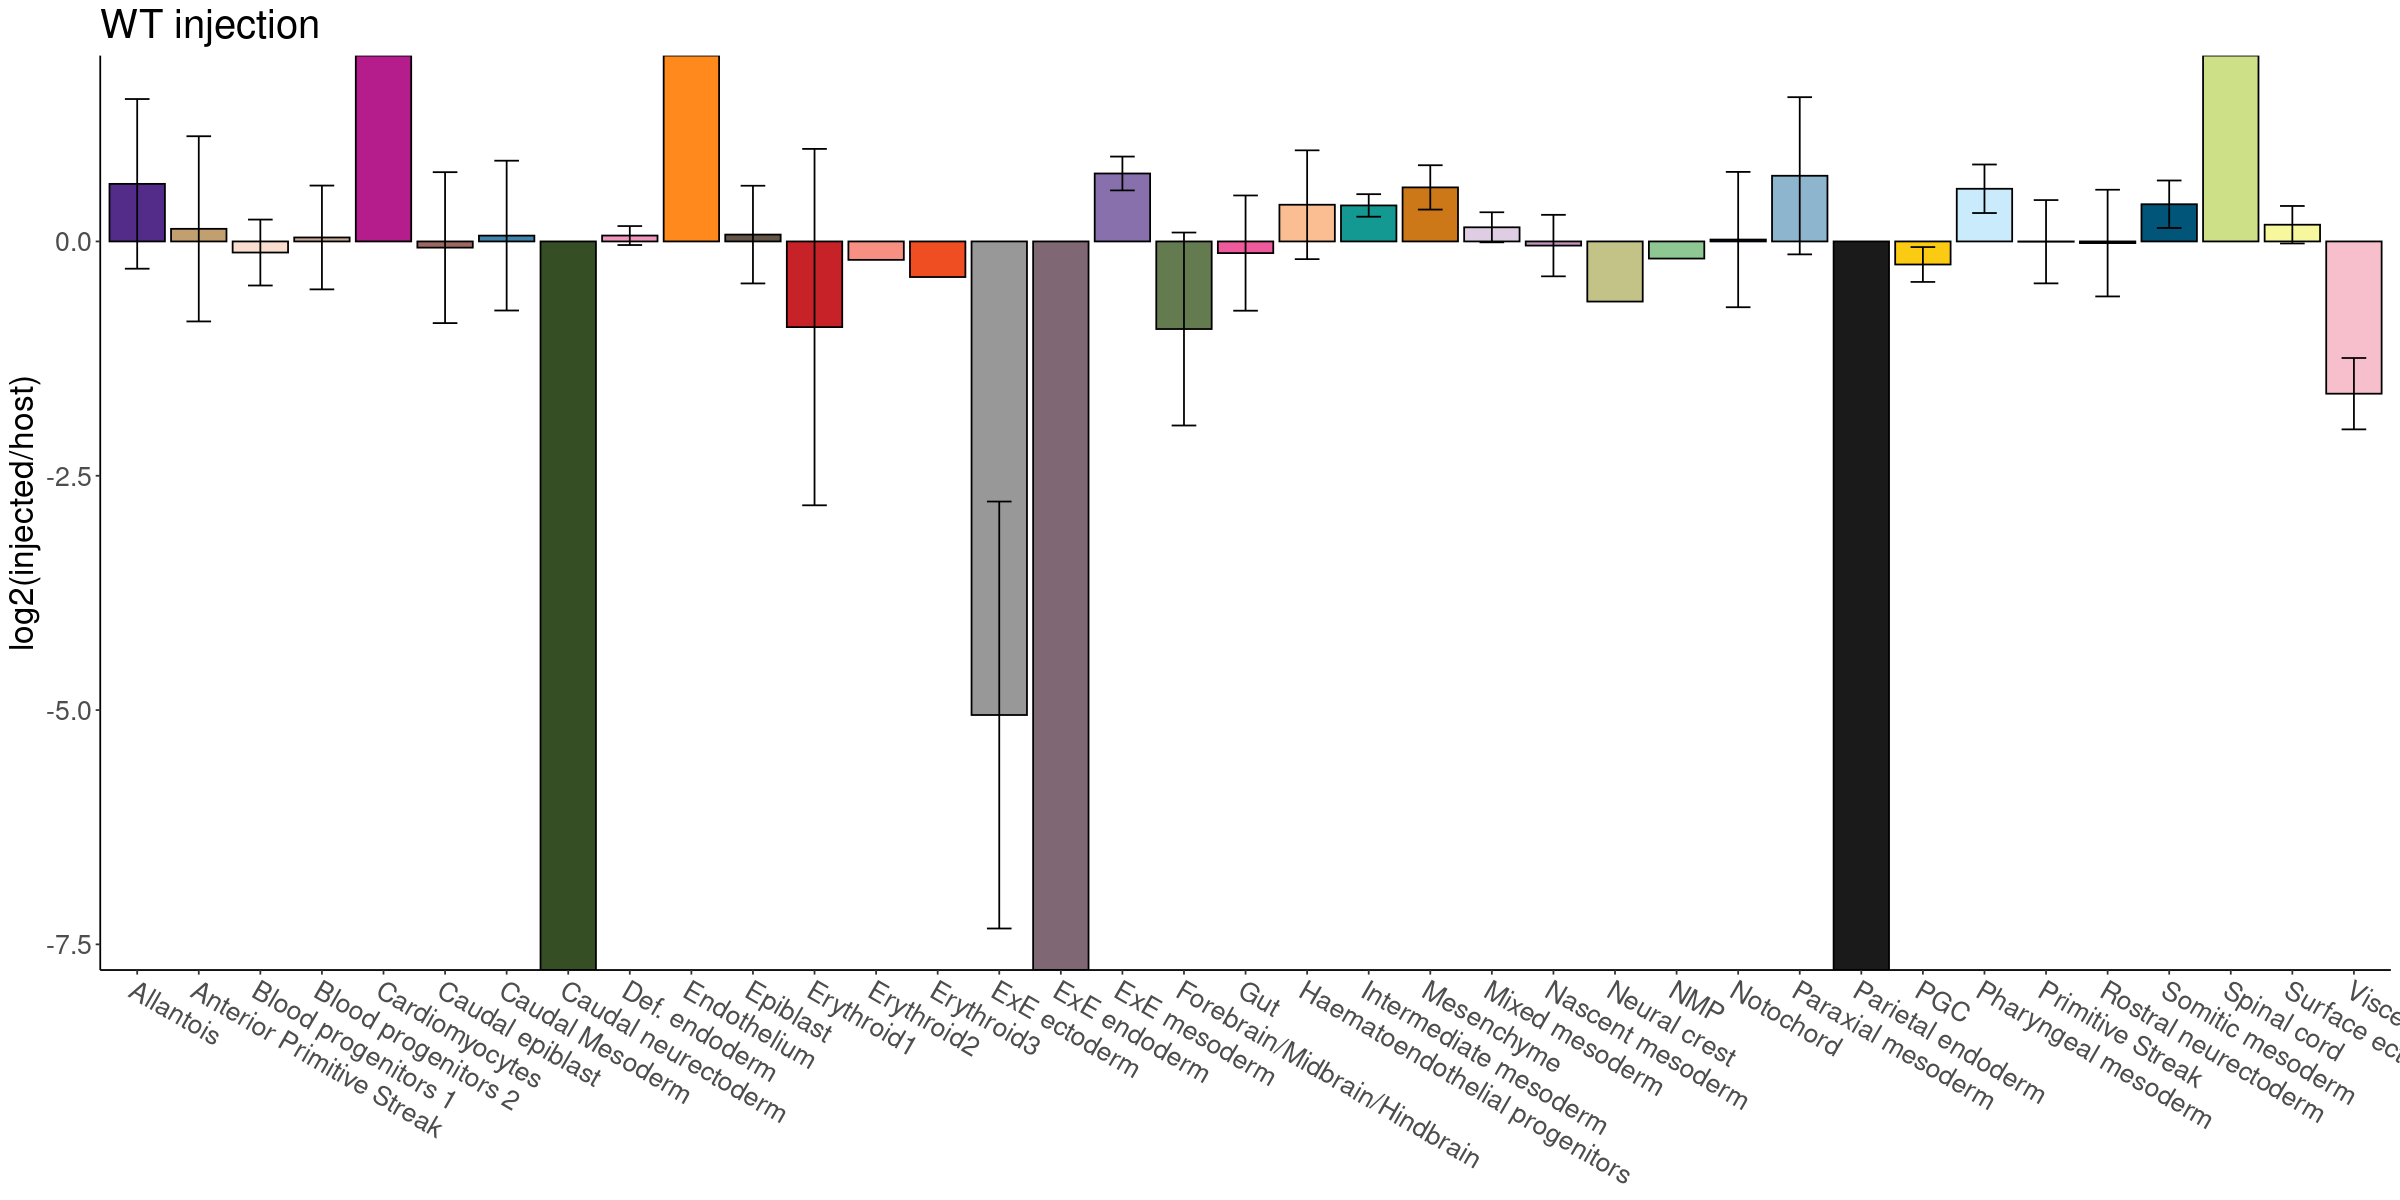

In [314]:
embryo1 <- c('1', '2') # not actually embryo but KO cell line pool
embryo2 <- c('3', '4')
embryo3 <- c('5', '6')

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tomato[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
ratio = spread(pdf1, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_1')
ratio1 = ratio

pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tomato[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
ratio = spread(pdf2, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_2')
ratio2 = ratio

pdf3 = table(meta$celltype.mapped[meta$sample %in% embryo3], meta$tomato[meta$sample %in% embryo3])
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
ratio = spread(pdf3, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_3')
ratio3 = ratio

merged = merge(ratio1, ratio2, by='Var1', all=TRUE)
merged = merge(merged, ratio3, by='Var1', all=TRUE)
merged$Var1 = factor(merged$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) 
merged_bu = merged
merged = gather(merged, sample, ratio, ratio_1:ratio_3)

merged = merged %>% group_by(Var1) %>% summarize(mean = mean(ratio, na.rm=TRUE), sd = sd(ratio, na.rm=TRUE))

ggplot(data = merged, mapping = aes(x = Var1, y = mean, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [224]:
head(pdf1)
head(ratio1)
head(merged_bu)
head(merged)

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,Allantois,FALSE,0.002046664
2,Anterior Primitive Streak,FALSE,0.002865330
3,Blood progenitors 1,FALSE,0.024559967
4,Blood progenitors 2,FALSE,0.035611953
5,Cardiomyocytes,FALSE,0.000000000
6,Caudal epiblast,FALSE,0.054850594


,Var1,ratio_1
,<fct>,<dbl>
1,Allantois,1.1696005
2,Anterior Primitive Streak,0.8331283
3,Blood progenitors 1,-0.5109333
4,Blood progenitors 2,0.2590404
5,Cardiomyocytes,Inf
6,Caudal epiblast,0.3807041


,Var1,ratio_1,ratio_2,ratio_3
,<fct>,<dbl>,<dbl>,<dbl>
1,Allantois,1.1696005,-0.43040406,1.1035941
2,Anterior Primitive Streak,0.8331283,-0.56393545,NA
3,Blood progenitors 1,-0.5109333,-0.01156082,0.1675007
4,Blood progenitors 2,0.2590404,-0.58719231,0.4551828
5,Cardiomyocytes,Inf,-0.27625338,0.6747485
6,Caudal epiblast,0.3807041,0.41689380,-0.9956501


Var1,mean,sd
<fct>,<dbl>,<dbl>
Allantois,0.61426350,0.9053104
Anterior Primitive Streak,0.13459641,0.9878732
Blood progenitors 1,-0.11833116,0.3515937
Blood progenitors 2,0.04234363,0.5539446
Cardiomyocytes,Inf,NaN
Caudal epiblast,-0.06601742,0.8052889


In [226]:
merged_wt = merged

`summarise()` ungrouping output (override with `.groups` argument)



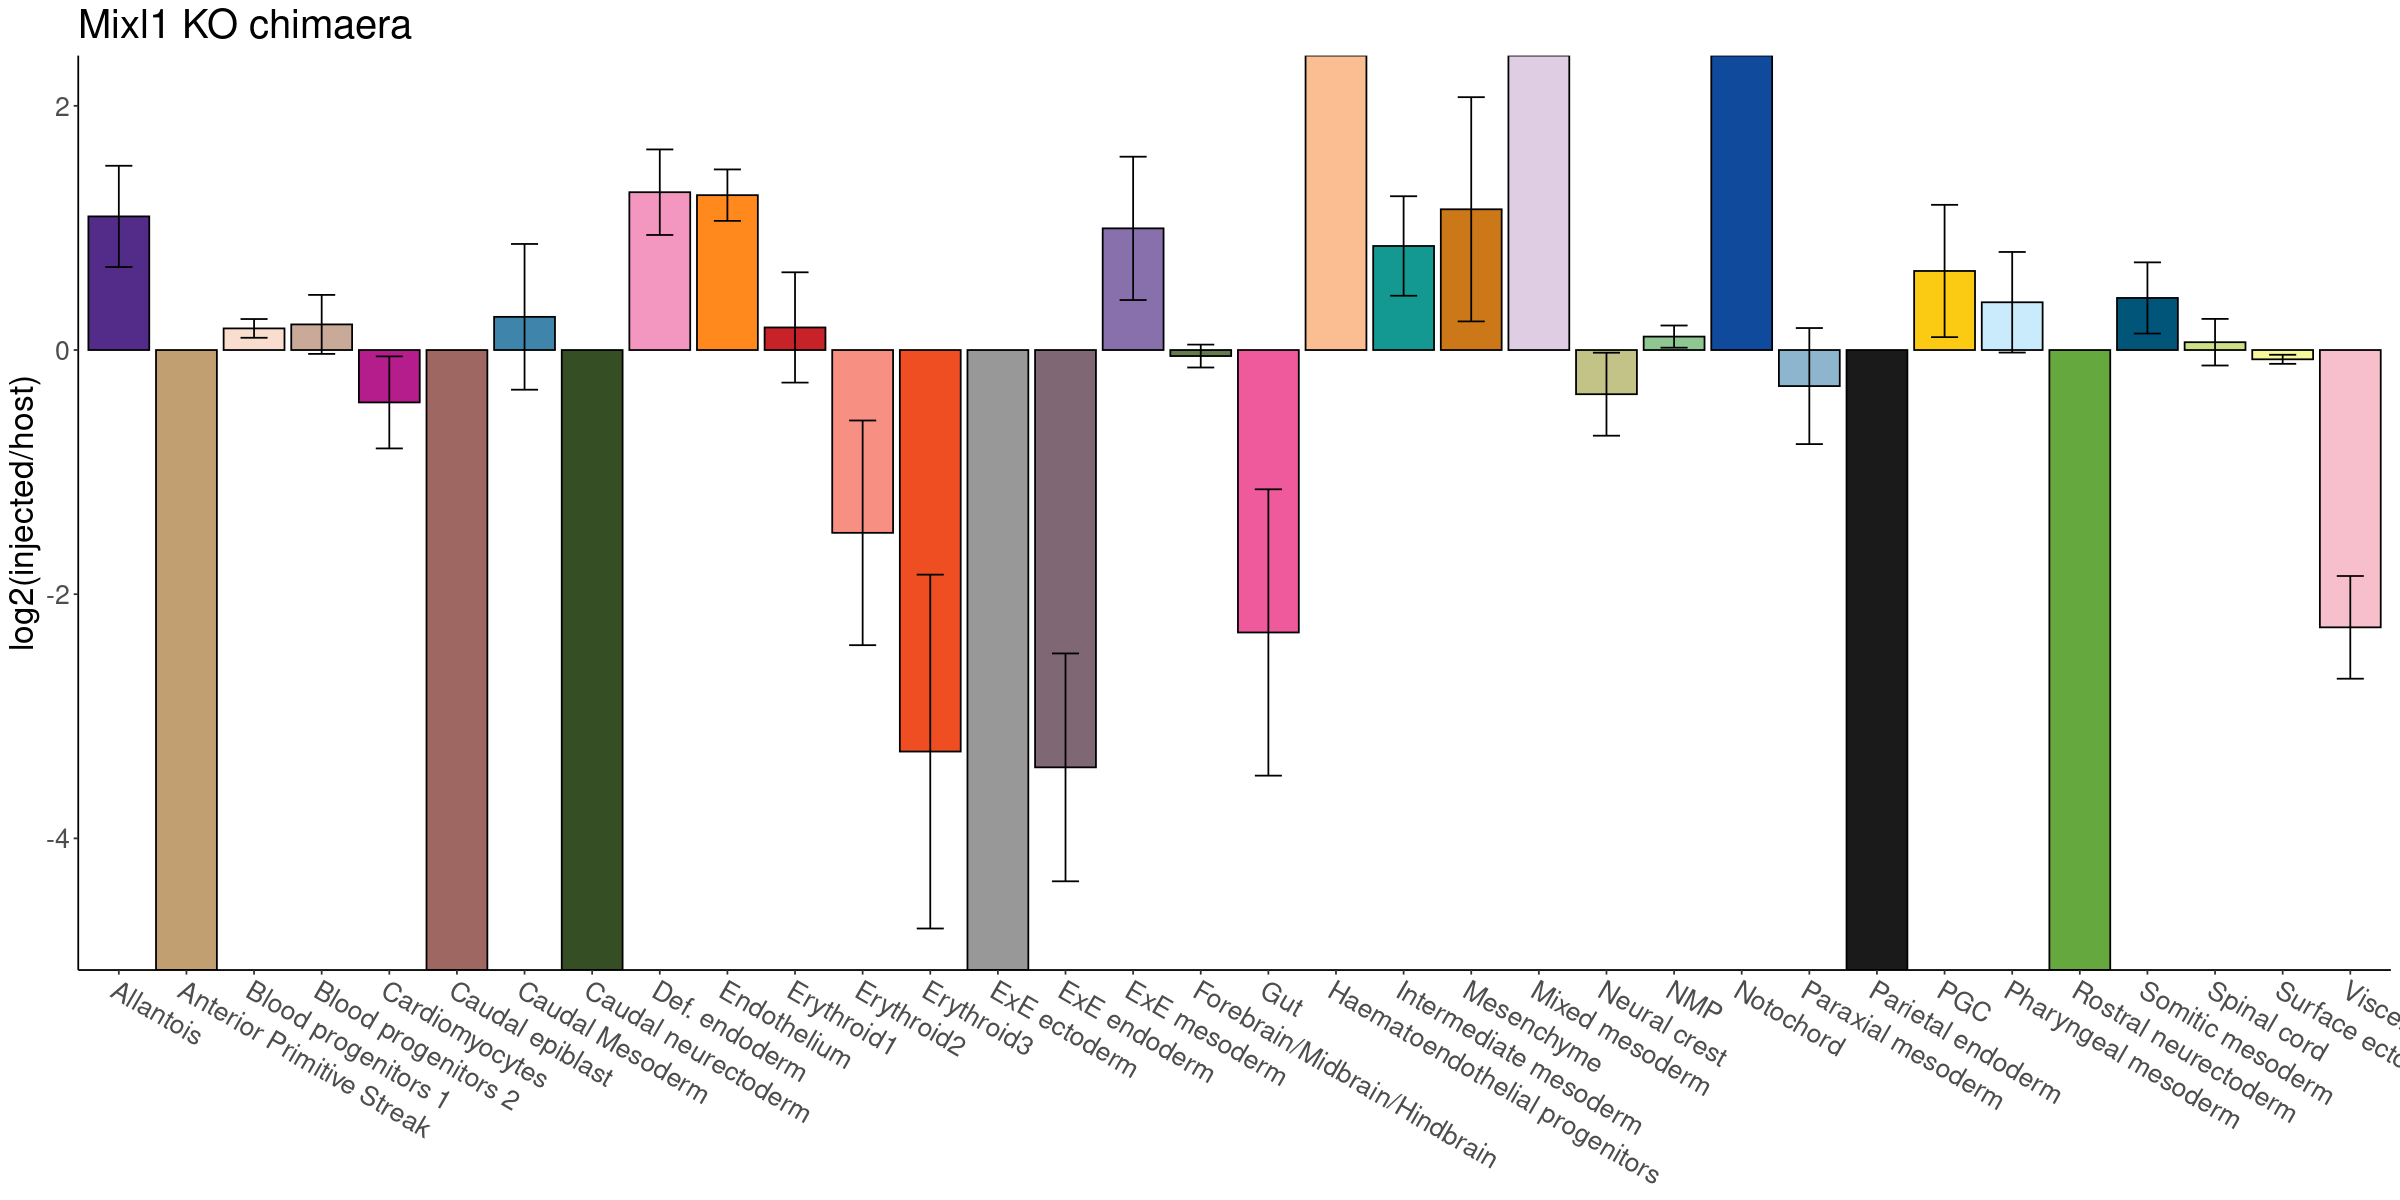

In [279]:
embryo1 <- c('mixl_1','mixl_2') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_3','mixl_4')
embryo3 <- c('mixl_6','mixl_5')

pdf1 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo1], own_meta$tdTom[own_meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
ratio = spread(pdf1, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_1')
ratio1 = ratio

pdf2 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo2], own_meta$tdTom[own_meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
ratio = spread(pdf2, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_2')
ratio2 = ratio

pdf3 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo3], own_meta$tdTom[own_meta$sample %in% embryo3])
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
ratio = spread(pdf3, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_3')
ratio3 = ratio

merged = merge(ratio1, ratio2, by='Var1', all=TRUE)
merged = merge(merged, ratio3, by='Var1', all=TRUE)
merged$Var1 = factor(merged$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])  
merged = gather(merged, sample, ratio, ratio_1:ratio_3)

merged = merged %>% group_by(Var1) %>% summarize(mean = mean(ratio, na.rm=TRUE), sd = sd(ratio, na.rm=TRUE))


ggplot(data = merged, mapping = aes(x = Var1, y = mean, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [300]:
head(merged)

Var1,mean,sd
<fct>,<dbl>,<dbl>
Allantois,0.61426350,0.9053104
Anterior Primitive Streak,0.13459641,0.9878732
Blood progenitors 1,-0.11833116,0.3515937
Blood progenitors 2,0.04234363,0.5539446
Cardiomyocytes,Inf,NaN
Caudal epiblast,-0.06601742,0.8052889


In [302]:
colnames(merged_wt) = c('Var1', 'mean_wt', 'sd_wt')
colnames(merged) = c('Var1', 'mean_ko', 'sd_ko')
merged2 = merge(merged_wt, merged, by='Var1')
merged2$ratio = merged2$mean_ko/merged2$mean_wt
merged2$sd = merged2$ratio*sqrt((merged2$sd_ko/merged2$mean_ko)^2 + (merged2$sd_wt/merged2$mean_wt)^2)

In [303]:
own_meta$count = 1
cellcount = own_meta %>% group_by(celltype.mapped) %>% summarize(cells = sum(count))
low_cell_nr = cellcount %>% filter(cells < 50) %>% .$celltype.mapped

`summarise()` ungrouping output (override with `.groups` argument)



In [304]:
## if KO is negative than becomes + if WT is also negative --> compensate for this
merged2$ratio = abs(merged2$ratio)
merged2$sign =  ifelse(merged2$mean_ko < 0,"negative", "positive")
merged2$ratio = ifelse(merged2$sign == 'negative', -1*merged2$ratio, merged2$ratio)

Warning message:
“Removed 3 rows containing missing values (geom_bar).”


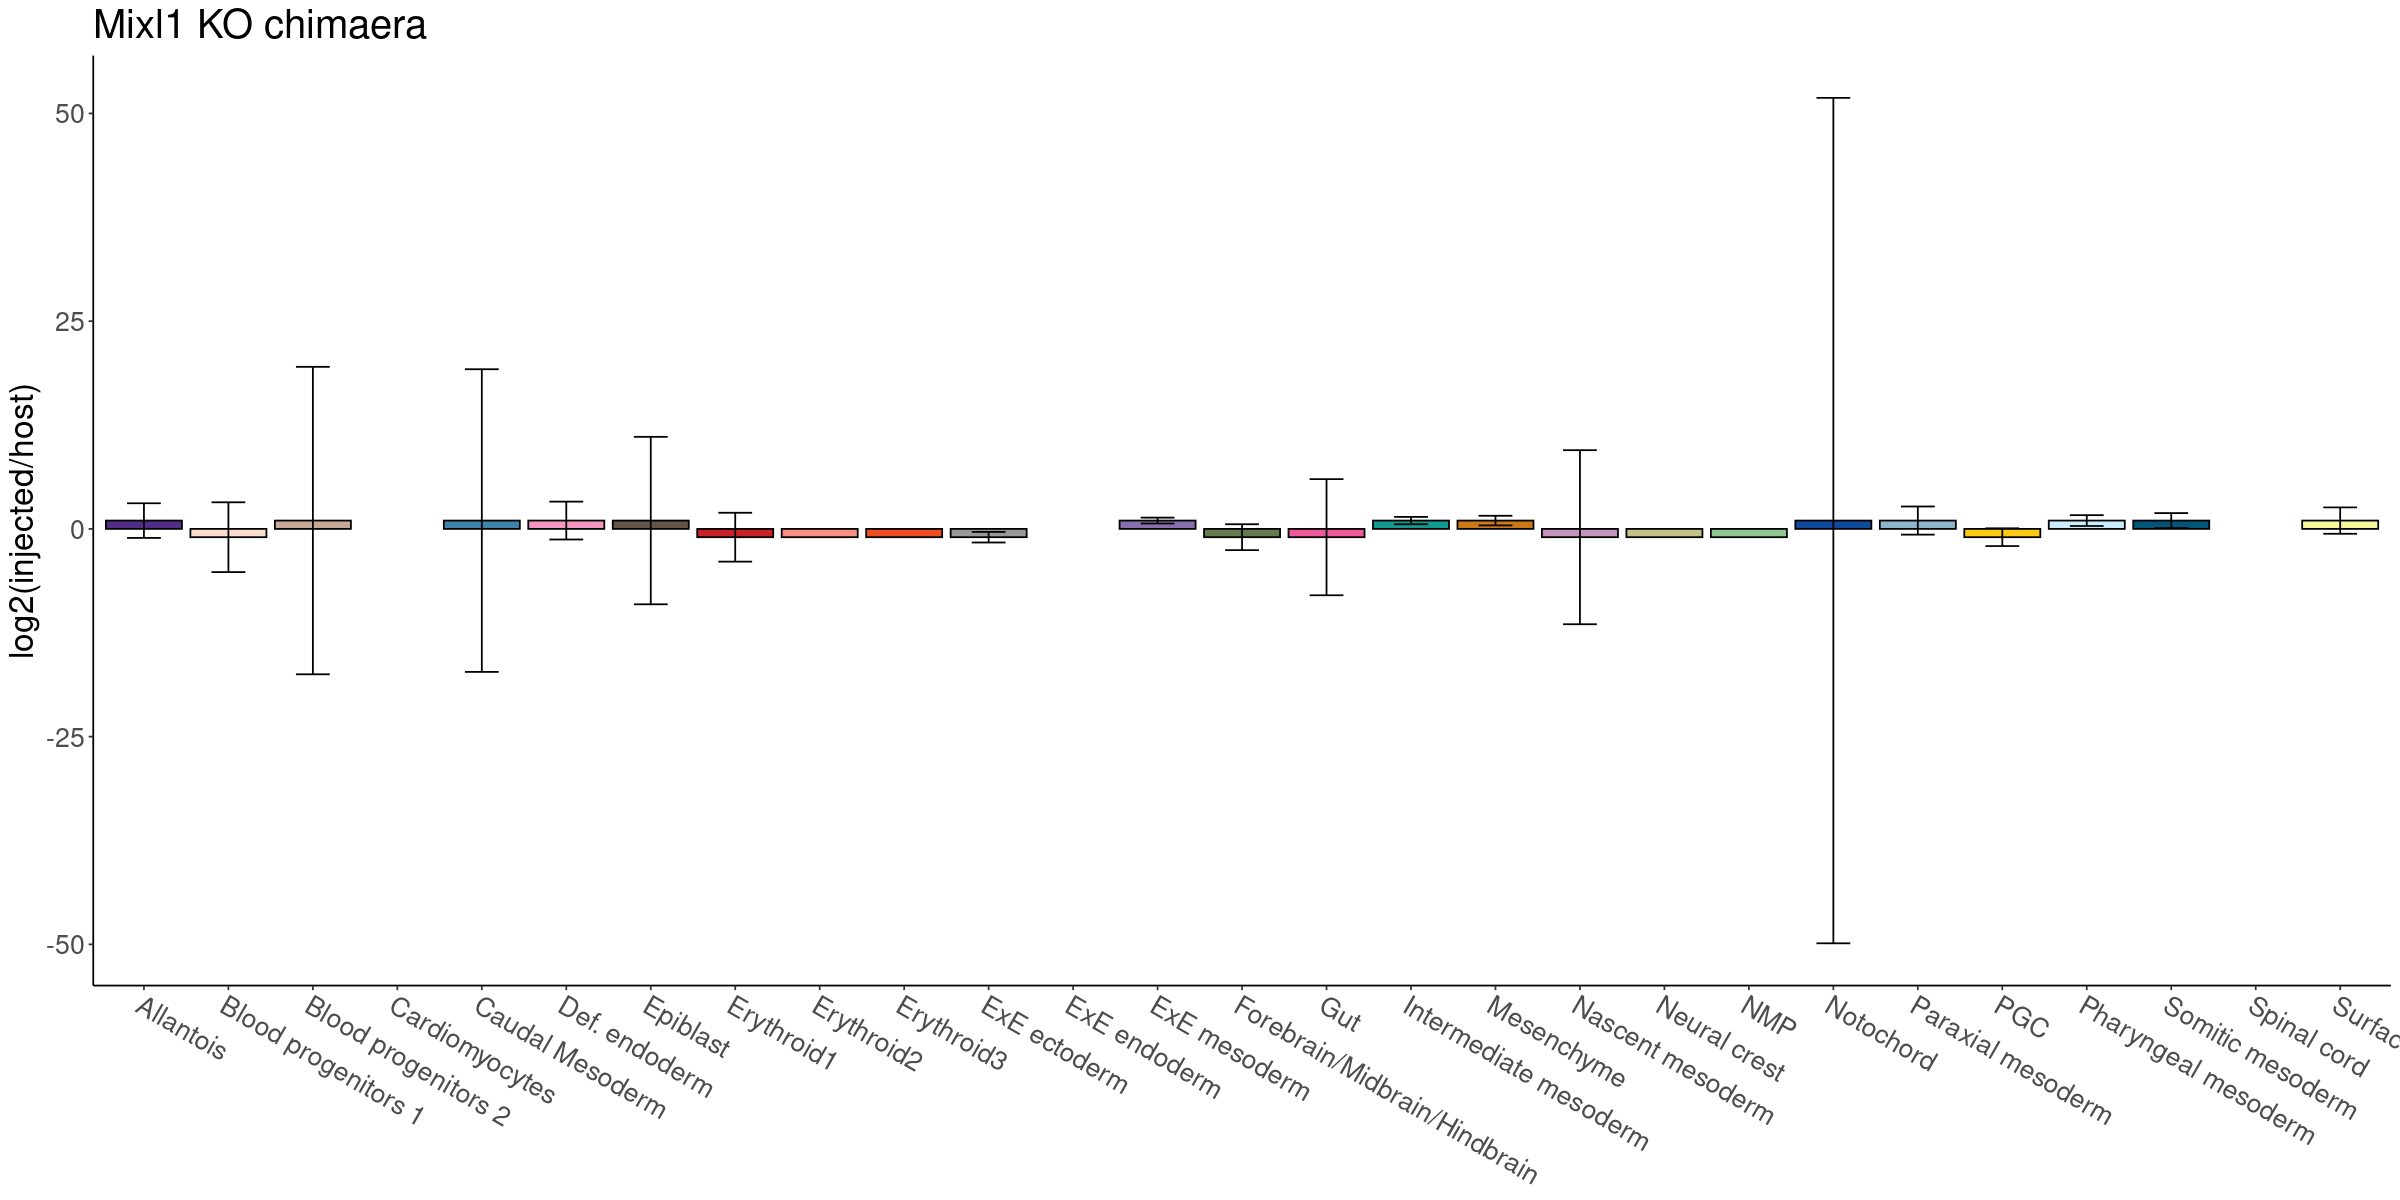

In [306]:
merged4 = merged2 %>% filter(!Var1 %in% low_cell_nr & Var1 != 'Primitive Streak') #### remove this!
ggplot(data = merged4, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [258]:
head(merged2)

,Var1,mean_wt,sd_wt,mean_ko,sd_ko,ratio,sd,sign
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Allantois,0.61426350,0.9053104,1.0945201,0.41470811,1.781841,2.711498,positive
2,Blood progenitors 1,-0.11833116,0.3515937,0.1769983,0.07667819,1.495787,-4.491378,positive
3,Blood progenitors 2,0.04234363,0.5539446,0.2098354,0.24166847,4.955537,65.079682,positive
4,Cardiomyocytes,Inf,NaN,-0.4292024,0.37696167,0.000000,NaN,negative
5,Caudal Mesoderm,0.06205223,0.7990983,0.2717239,0.59686874,4.378954,57.205910,positive
6,Def. endoderm,0.06282342,0.1012292,1.2926519,0.35021091,20.575955,33.620010,positive


In [286]:
means = merged2 %>% select(Var1, mean_wt, mean_ko)
colnames(means) = c('Var1', 'WT', 'KO')
means = gather(means, experiment, mean, -Var1)

sd = merged2 %>% select(Var1, sd_wt, sd_ko)
colnames(sd) = c('Var1', 'WT', 'KO')
sd = gather(sd, experiment, sd, -Var1)

merged3 = merge(means, sd, by=c('Var1', 'experiment'))


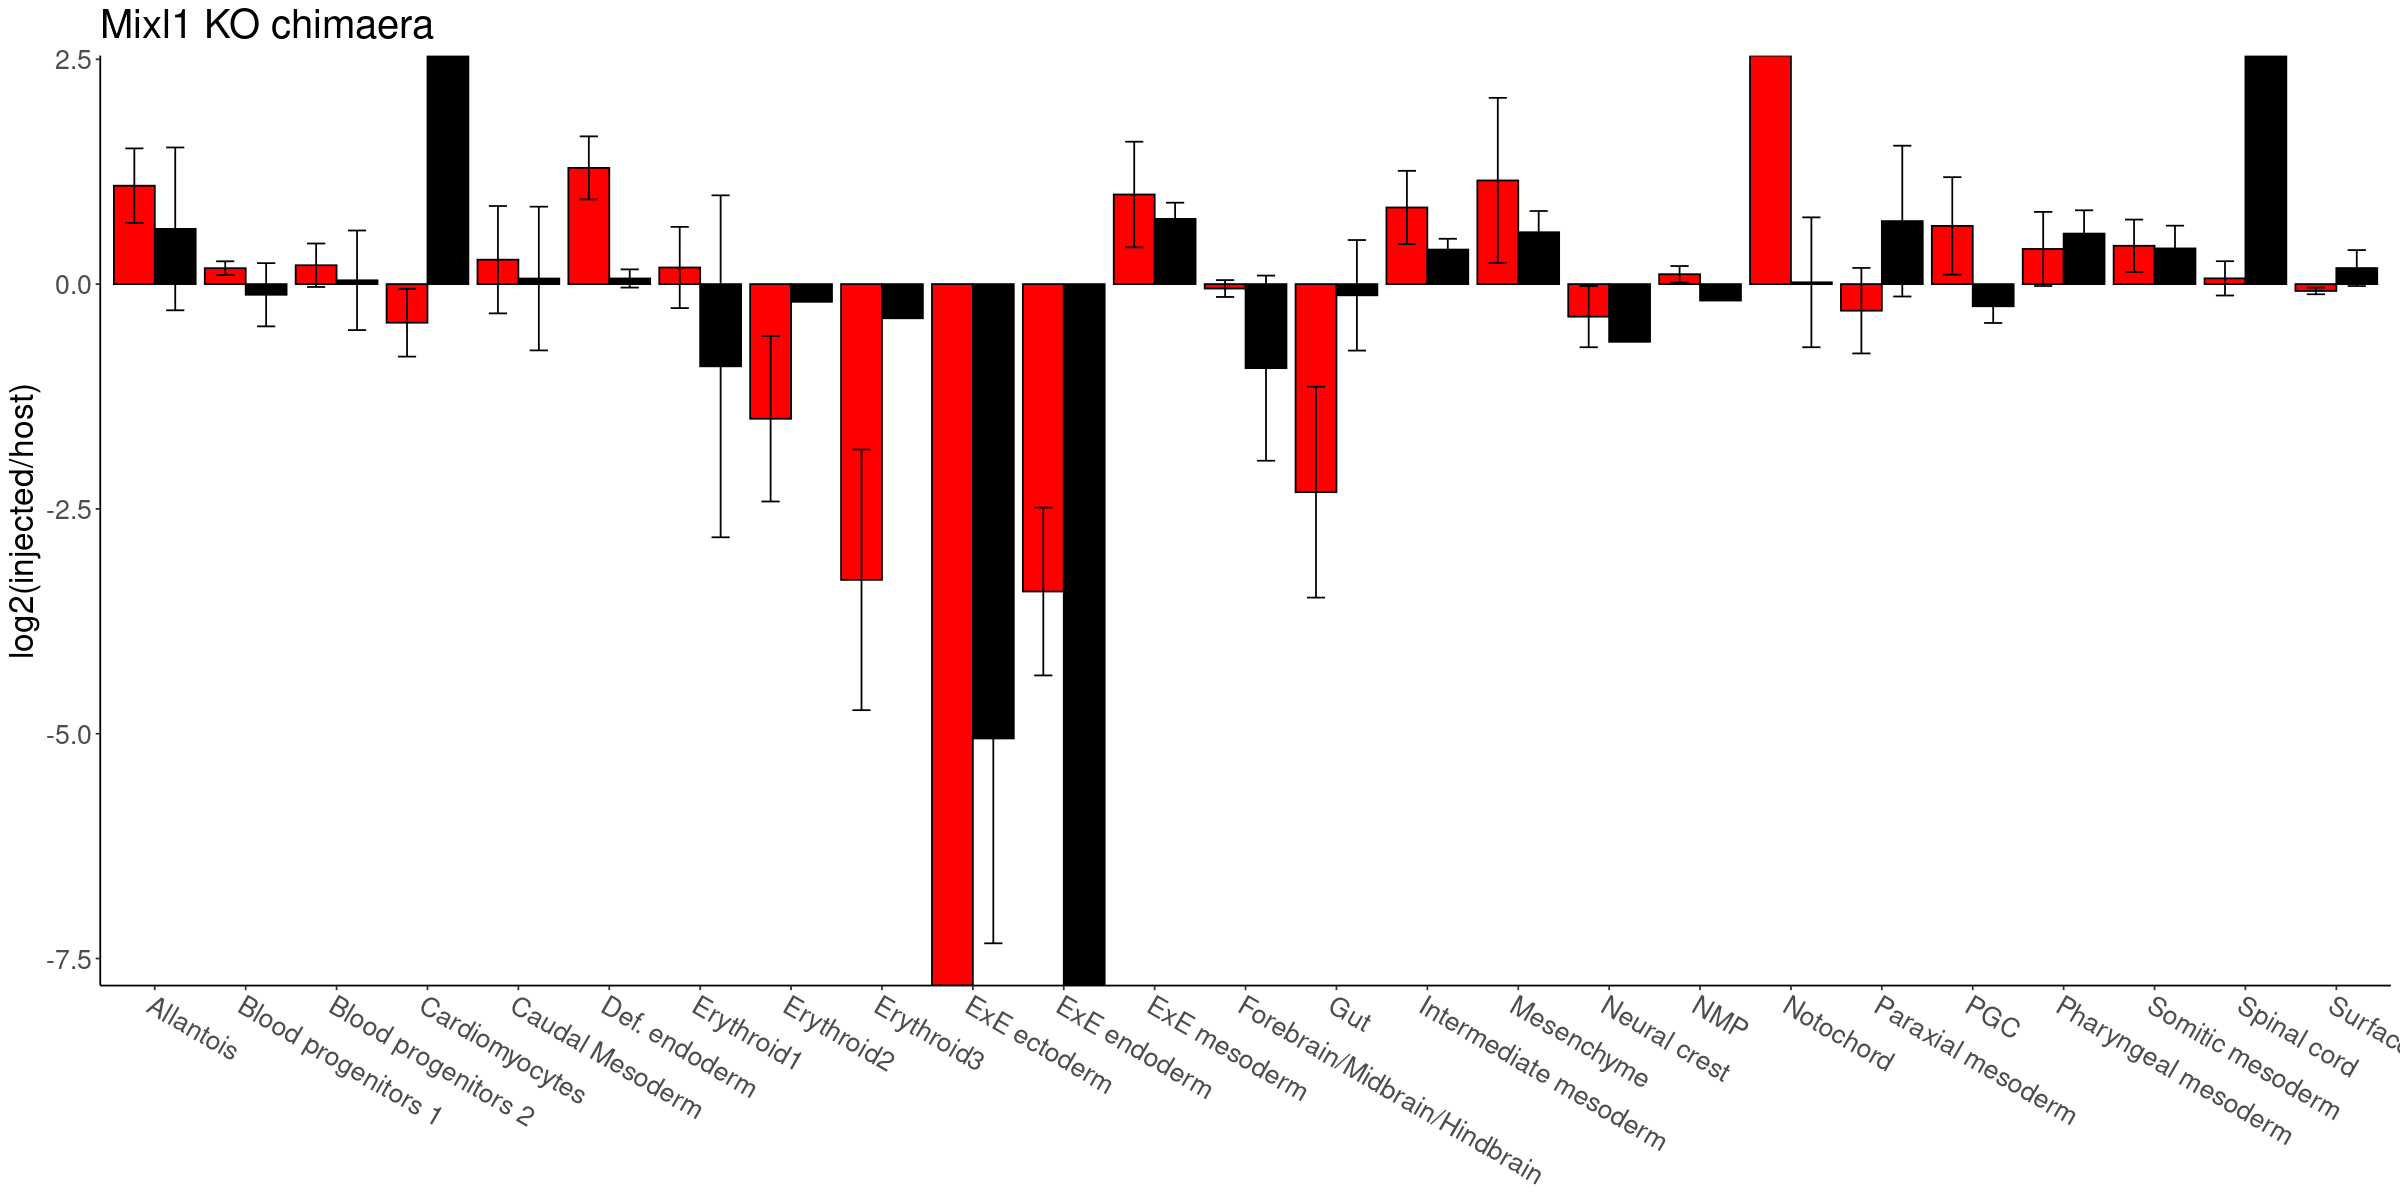

In [277]:
ggplot(data = merged3, mapping = aes(x = Var1, y = mean, fill=experiment)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
   scale_fill_manual(values = c("KO" = "red", "WT" = "black")) +
#  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

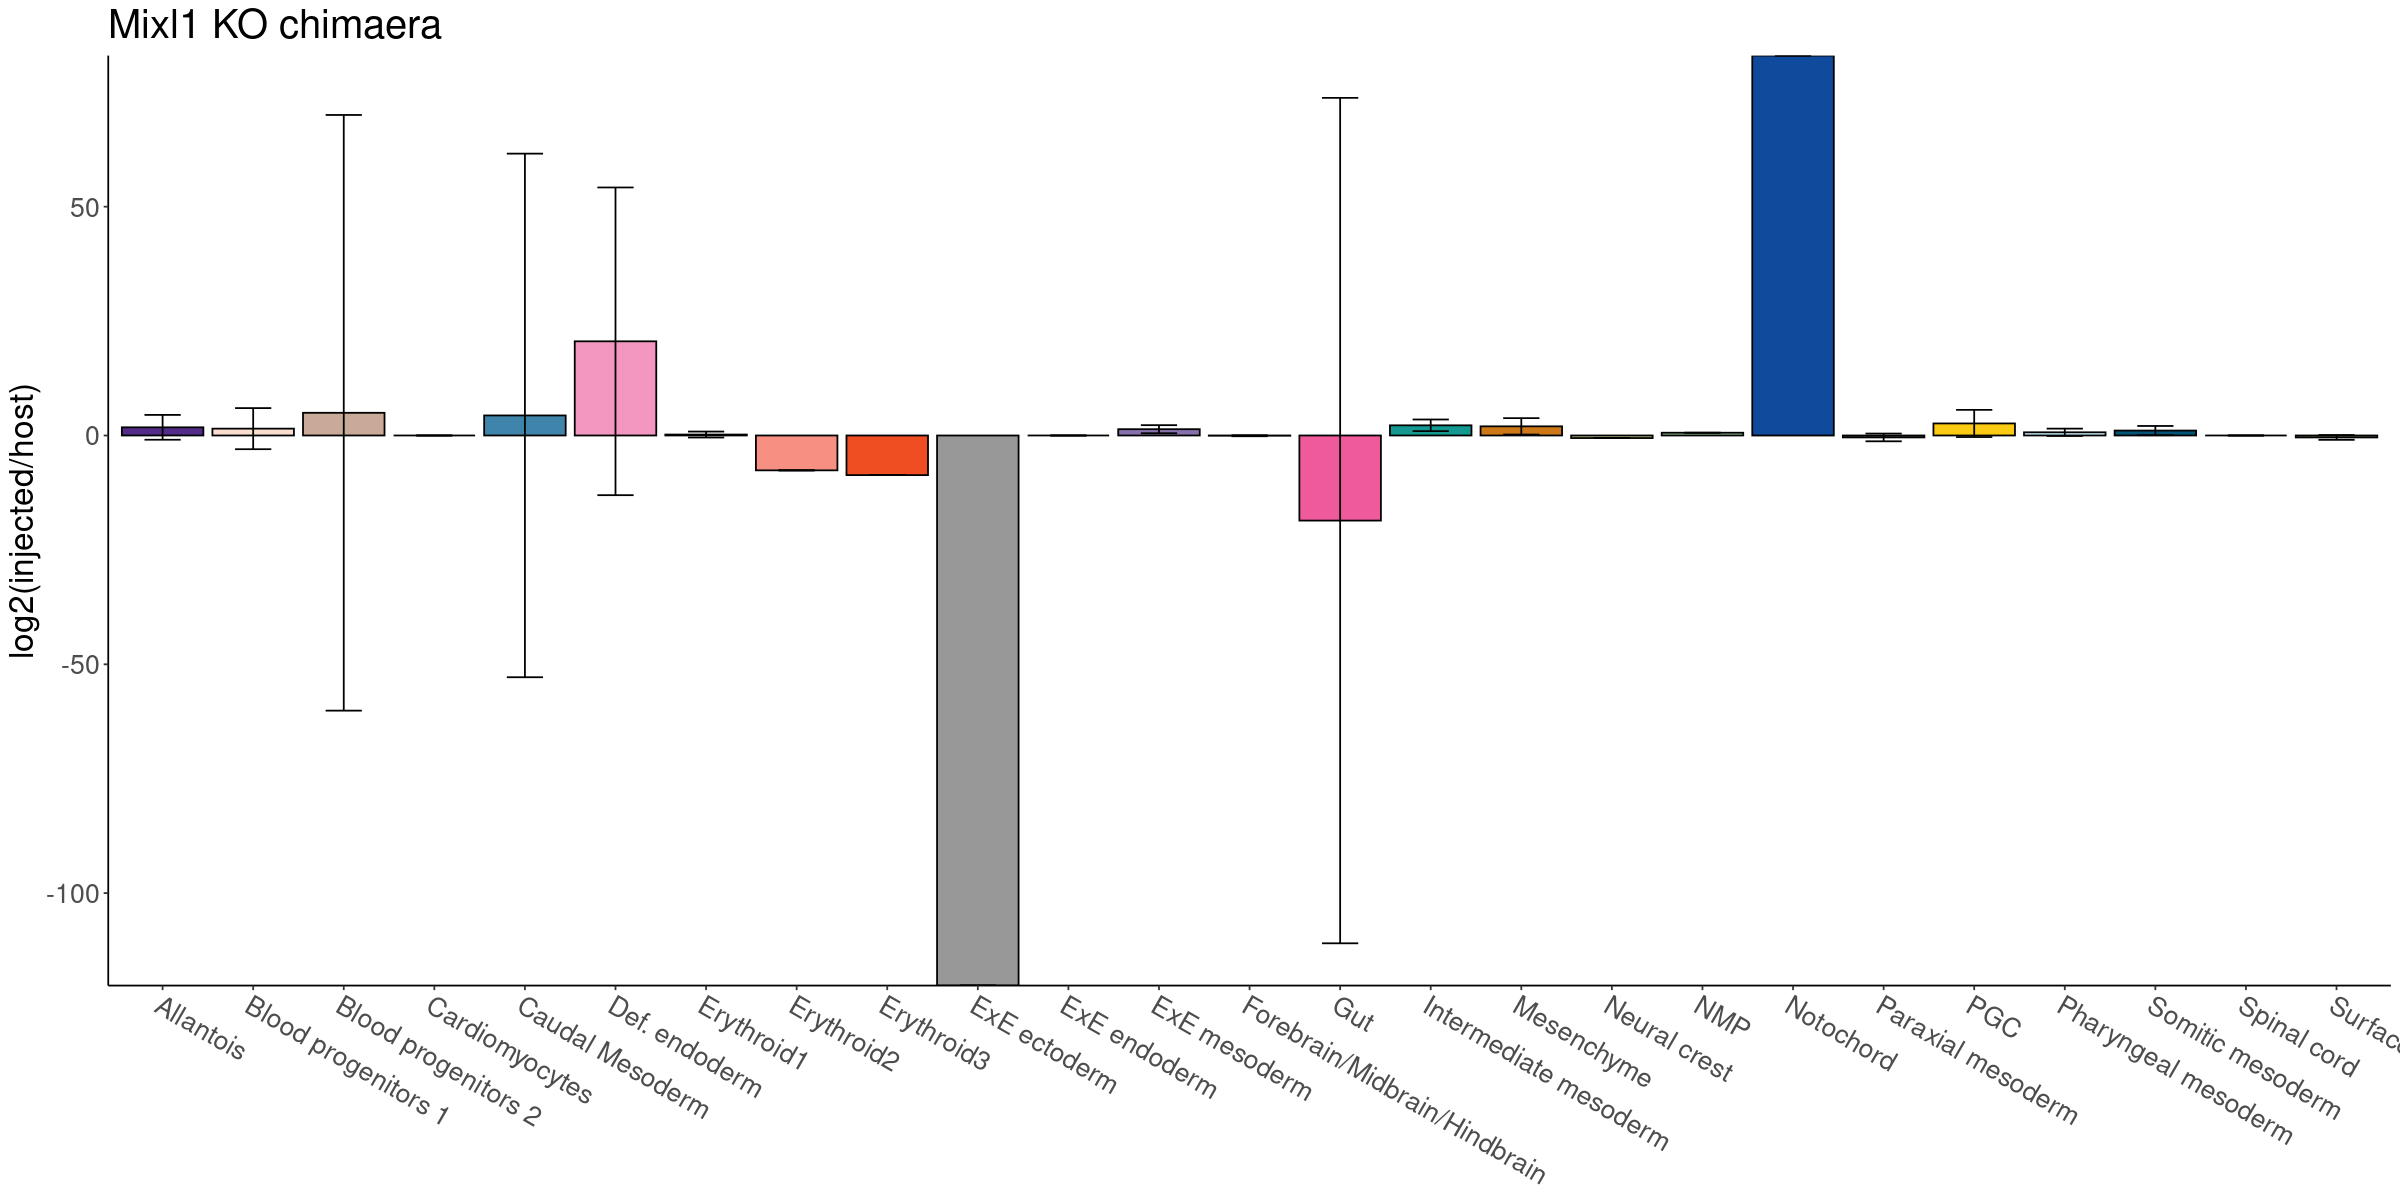

In [301]:
merged2 = merged2 %>% filter(!Var1 %in% low_cell_nr)
ggplot(data = merged2, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [295]:
head(merged3)

,Var1,experiment,mean,sd
,<fct>,<chr>,<dbl>,<dbl>
1,Allantois,KO,1.09452009,0.41470811
2,Allantois,WT,0.61426350,0.90531041
3,Blood progenitors 1,KO,0.17699826,0.07667819
4,Blood progenitors 1,WT,-0.11833116,0.35159367
5,Blood progenitors 2,KO,0.20983543,0.24166847
6,Blood progenitors 2,WT,0.04234363,0.55394456


In [195]:
ratio = spread(pdf1, Var2, Freq)

In [196]:
head(ratio)

,Var1,neg,pos
,<fct>,<dbl>,<dbl>
1,Allantois,4.075772e-02,0.1121930789
2,Anterior Primitive Streak,5.522726e-05,0.0000000000
3,Blood progenitors 1,3.092727e-03,0.0037170829
4,Blood progenitors 2,1.159772e-02,0.0130883200
5,Cardiomyocytes,3.816204e-02,0.0279566515
6,Caudal epiblast,2.209090e-04,0.0001570598


## adding 0.001 to fraction to remove infinite values

`summarise()` ungrouping output (override with `.groups` argument)



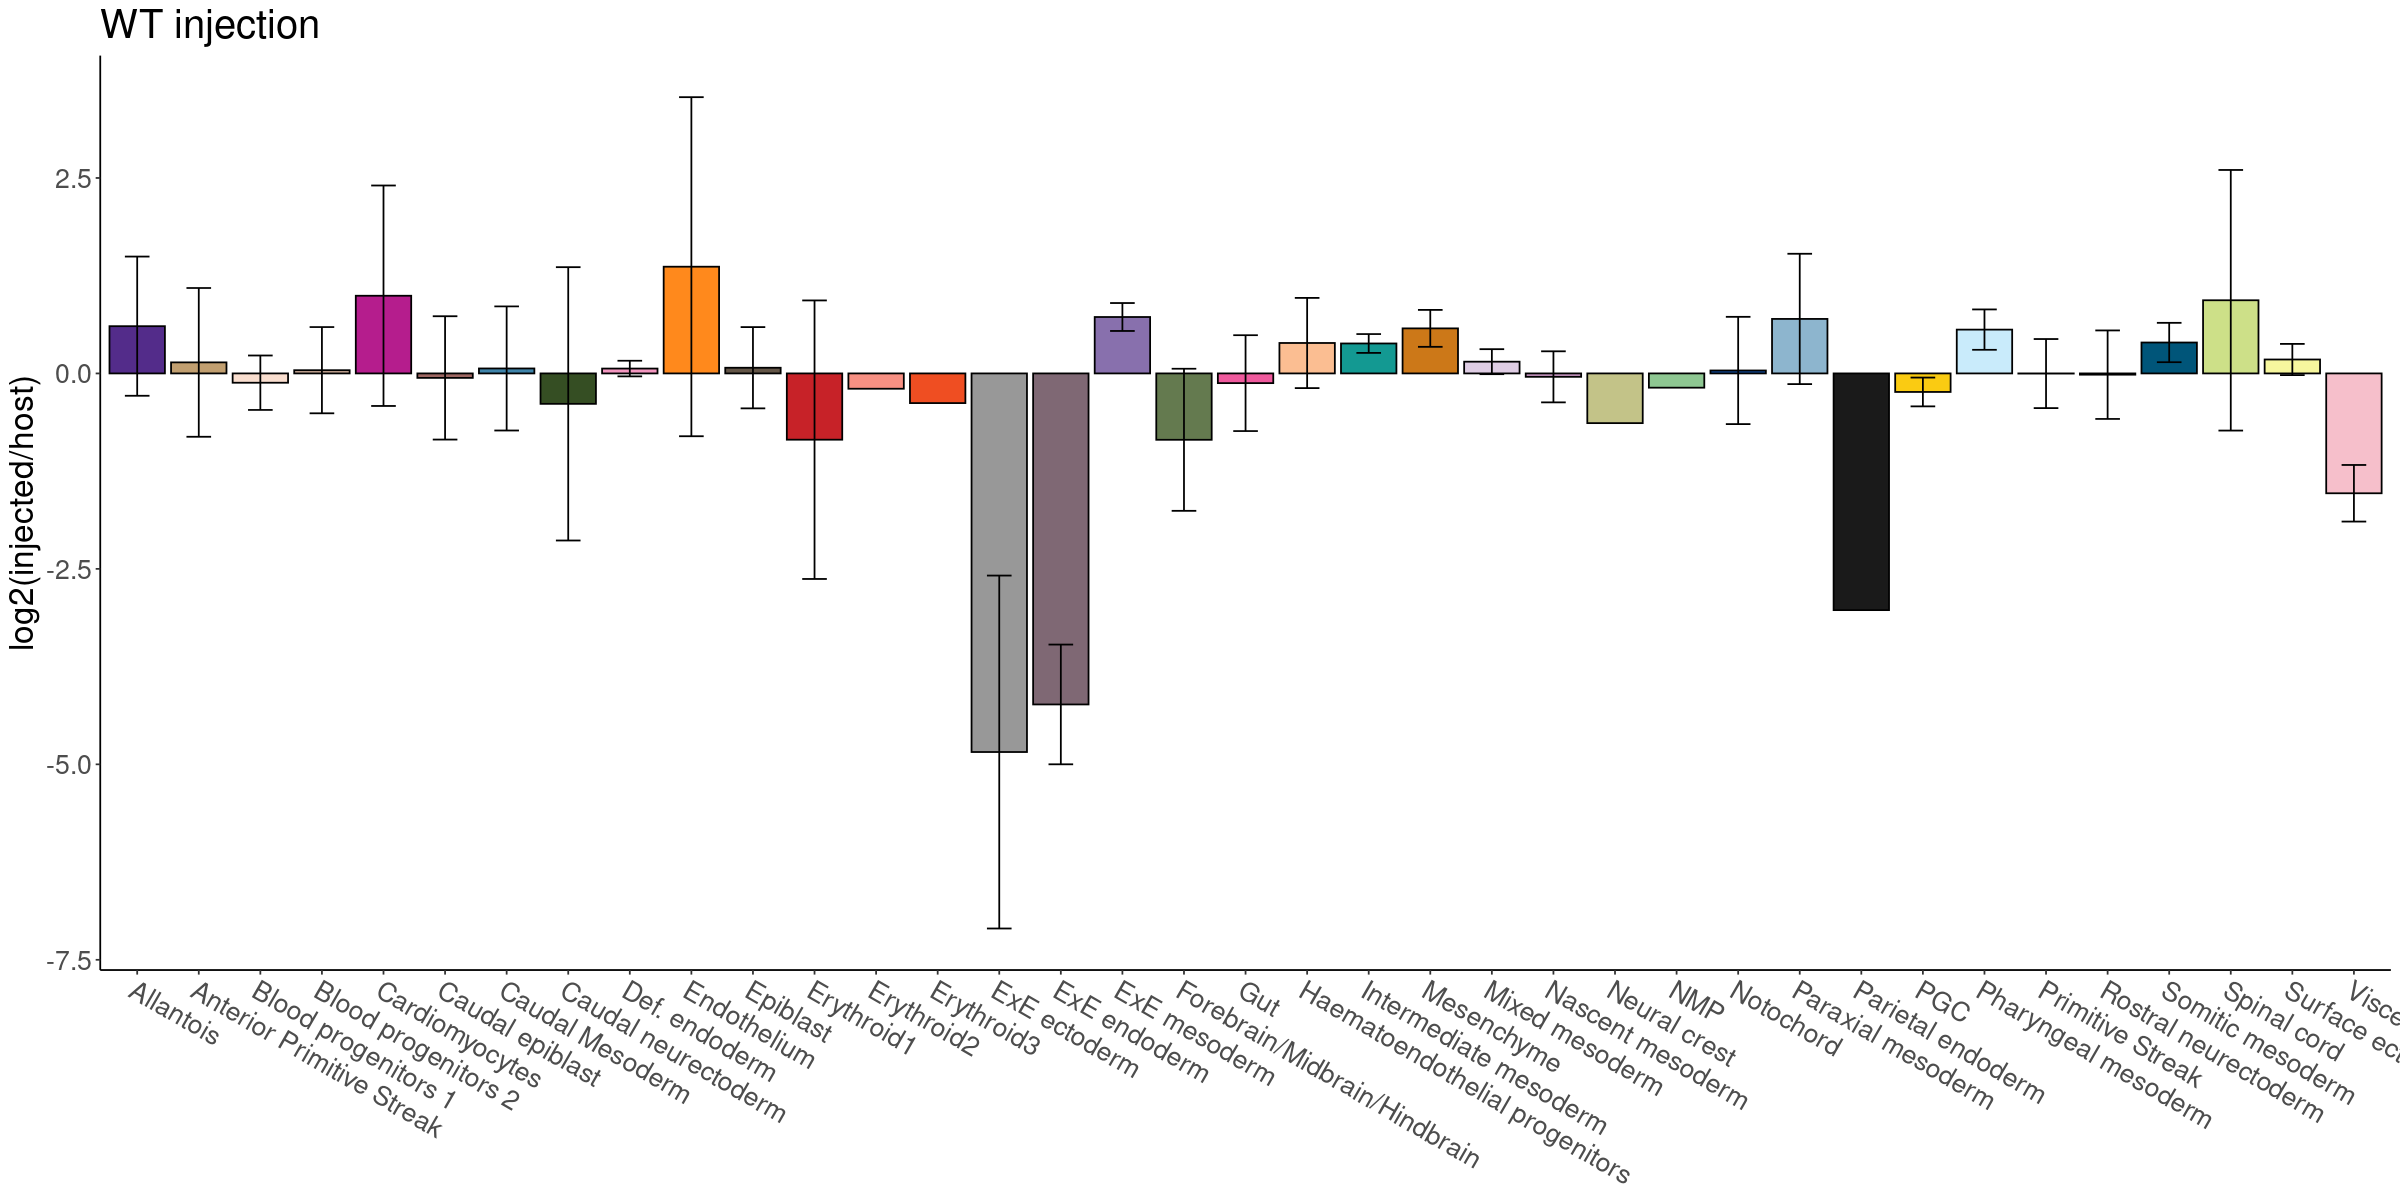

In [319]:
embryo1 <- c('1', '2') # not actually embryo but KO cell line pool
embryo2 <- c('3', '4')
embryo3 <- c('5', '6')

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tomato[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Freq = pdf1$Freq + 0.0001

ratio = spread(pdf1, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_1')
ratio1 = ratio

pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tomato[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf2$Freq = pdf2$Freq + 0.0001

ratio = spread(pdf2, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_2')
ratio2 = ratio

pdf3 = table(meta$celltype.mapped[meta$sample %in% embryo3], meta$tomato[meta$sample %in% embryo3])
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.0001

ratio = spread(pdf3, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_3')
ratio3 = ratio

merged = merge(ratio1, ratio2, by='Var1', all=TRUE)
merged = merge(merged, ratio3, by='Var1', all=TRUE)
merged$Var1 = factor(merged$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) 
merged_bu = merged
merged = gather(merged, sample, ratio, ratio_1:ratio_3)

merged = merged %>% group_by(Var1) %>% summarize(mean = mean(ratio, na.rm=TRUE), sd = sd(ratio, na.rm=TRUE))

ggplot(data = merged, mapping = aes(x = Var1, y = mean, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [320]:
merged_wt = merged

`summarise()` ungrouping output (override with `.groups` argument)



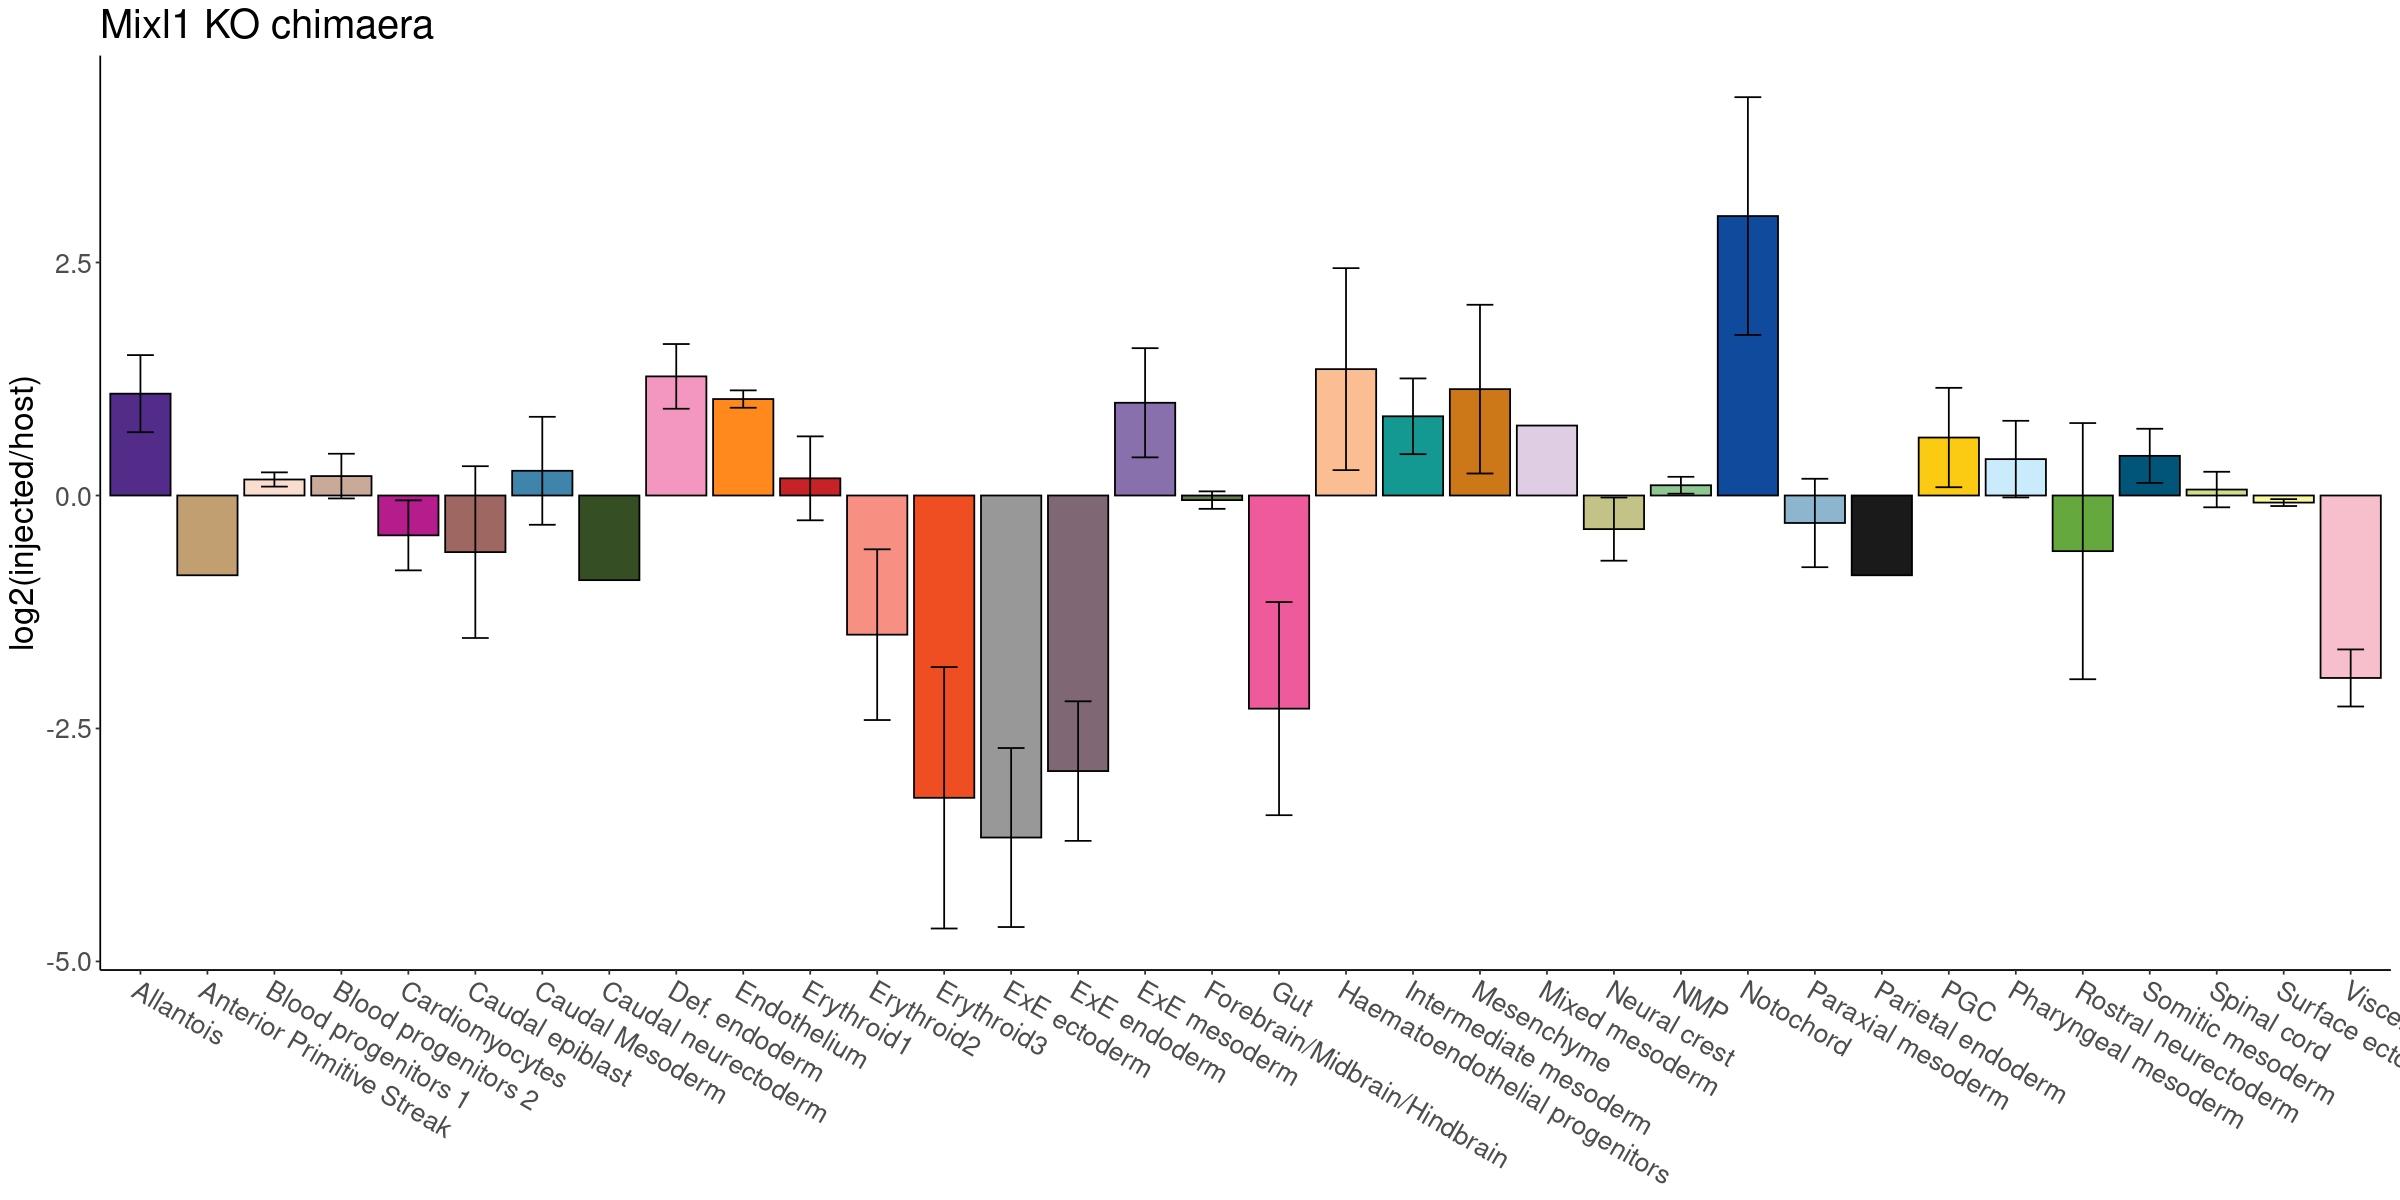

In [321]:
embryo1 <- c('mixl_1','mixl_2') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_3','mixl_4')
embryo3 <- c('mixl_6','mixl_5')

pdf1 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo1], own_meta$tdTom[own_meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Freq = pdf1$Freq + 0.0001

ratio = spread(pdf1, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_1')
ratio1 = ratio

pdf2 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo2], own_meta$tdTom[own_meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf2$Freq = pdf2$Freq + 0.0001

ratio = spread(pdf2, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_2')
ratio2 = ratio

pdf3 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo3], own_meta$tdTom[own_meta$sample %in% embryo3])
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.0001

ratio = spread(pdf3, Var2, Freq)
colnames(ratio) = c('Var1', 'host', 'injected')
ratio$ratio = log(ratio$injected/ratio$host)
ratio = ratio %>% select(Var1, ratio)
colnames(ratio) = c('Var1', 'ratio_3')
ratio3 = ratio

merged = merge(ratio1, ratio2, by='Var1', all=TRUE)
merged = merge(merged, ratio3, by='Var1', all=TRUE)
merged$Var1 = factor(merged$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])  
merged = gather(merged, sample, ratio, ratio_1:ratio_3)

merged = merged %>% group_by(Var1) %>% summarize(mean = mean(ratio, na.rm=TRUE), sd = sd(ratio, na.rm=TRUE))


ggplot(data = merged, mapping = aes(x = Var1, y = mean, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [329]:
colnames(merged_wt) = c('Var1', 'mean_wt', 'sd_wt')
colnames(merged) = c('Var1', 'mean_ko', 'sd_ko')
merged2 = merge(merged_wt, merged, by='Var1')
merged2$ratio = merged2$mean_ko/merged2$mean_wt
merged2$sd = merged2$ratio*sqrt((merged2$sd_ko/merged2$mean_ko)^2 + (merged2$sd_wt/merged2$mean_wt)^2)

In [330]:
own_meta$count = 1
cellcount = own_meta %>% group_by(celltype.mapped) %>% summarize(cells = sum(count))
low_cell_nr = cellcount %>% filter(cells < 50) %>% .$celltype.mapped

`summarise()` ungrouping output (override with `.groups` argument)



In [331]:
## if KO is negative than becomes + if WT is also negative --> compensate for this
merged2$ratio = abs(merged2$ratio)
merged2$sign =  ifelse(merged2$mean_ko < 0,"negative", "positive")
merged2$ratio = ifelse(merged2$sign == 'negative', -1*merged2$ratio, merged2$ratio)

In [346]:
tail(merged2,20)

,Var1,mean_wt,sd_wt,mean_ko,sd_ko,ratio,sd,sign
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
15,ExE endoderm,-4.23404160,0.7656439,-2.95706042,0.74889788,-0.69840136,0.2173353,negative
16,ExE mesoderm,0.72149238,0.1786103,0.99500762,0.58574645,1.37909650,0.8807178,positive
17,Forebrain/Midbrain/Hindbrain,-0.84894089,0.9087310,-0.04930025,0.09372872,-0.05807266,0.1267037,negative
18,Gut,-0.12418856,0.6131118,-2.28729553,1.14332552,-18.41792481,91.3931180,negative
19,Haematoendothelial progenitors,0.38929658,0.5767938,1.35602783,1.08381153,3.48327699,5.8639574,positive
20,Intermediate mesoderm,0.38298895,0.1203484,0.85000663,0.40633416,2.21940251,1.2696502,positive
21,Mesenchyme,0.57609429,0.2360890,1.14135097,0.90514922,1.98118777,1.7685621,positive
22,Mixed mesoderm,0.15016209,0.1599581,0.75068144,NA,4.99914082,NA,positive
23,Neural crest,-0.63580887,NA,-0.36083716,0.33901284,-0.56752458,NA,negative


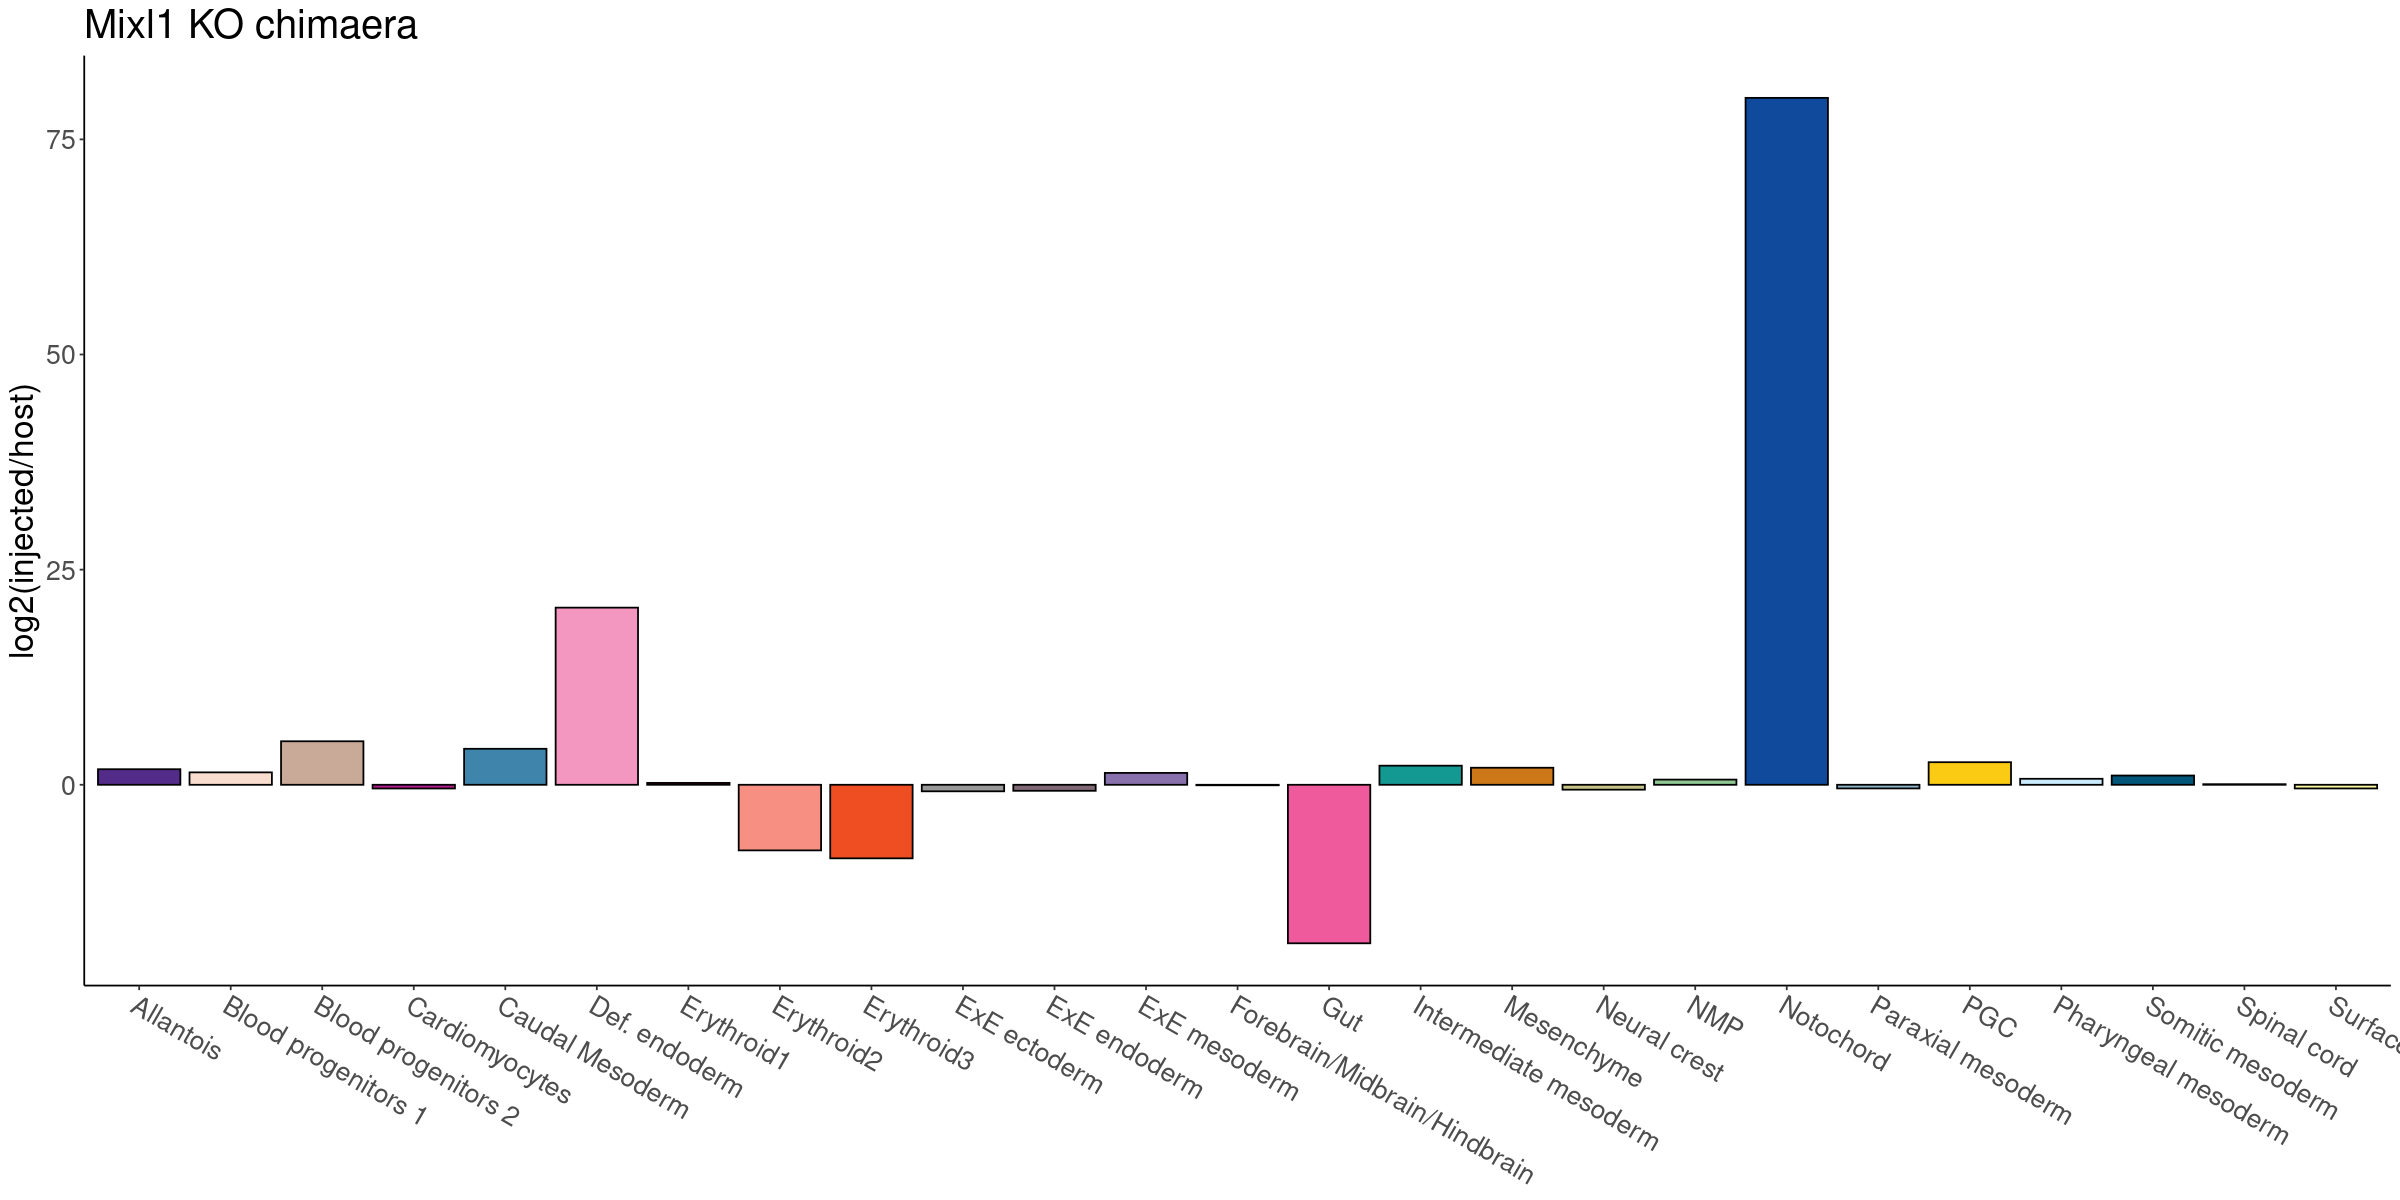

In [347]:
exclude = c('')
merged4 = merged2 %>% filter(!Var1 %in% low_cell_nr & !Var1 %in% exclude) #### remove this!
ggplot(data = merged4, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
#    geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
#                  position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [326]:
means = merged2 %>% select(Var1, mean_wt, mean_ko)
colnames(means) = c('Var1', 'WT', 'KO')
means = gather(means, experiment, mean, -Var1)

sd = merged2 %>% select(Var1, sd_wt, sd_ko)
colnames(sd) = c('Var1', 'WT', 'KO')
sd = gather(sd, experiment, sd, -Var1)

merged3 = merge(means, sd, by=c('Var1', 'experiment'))


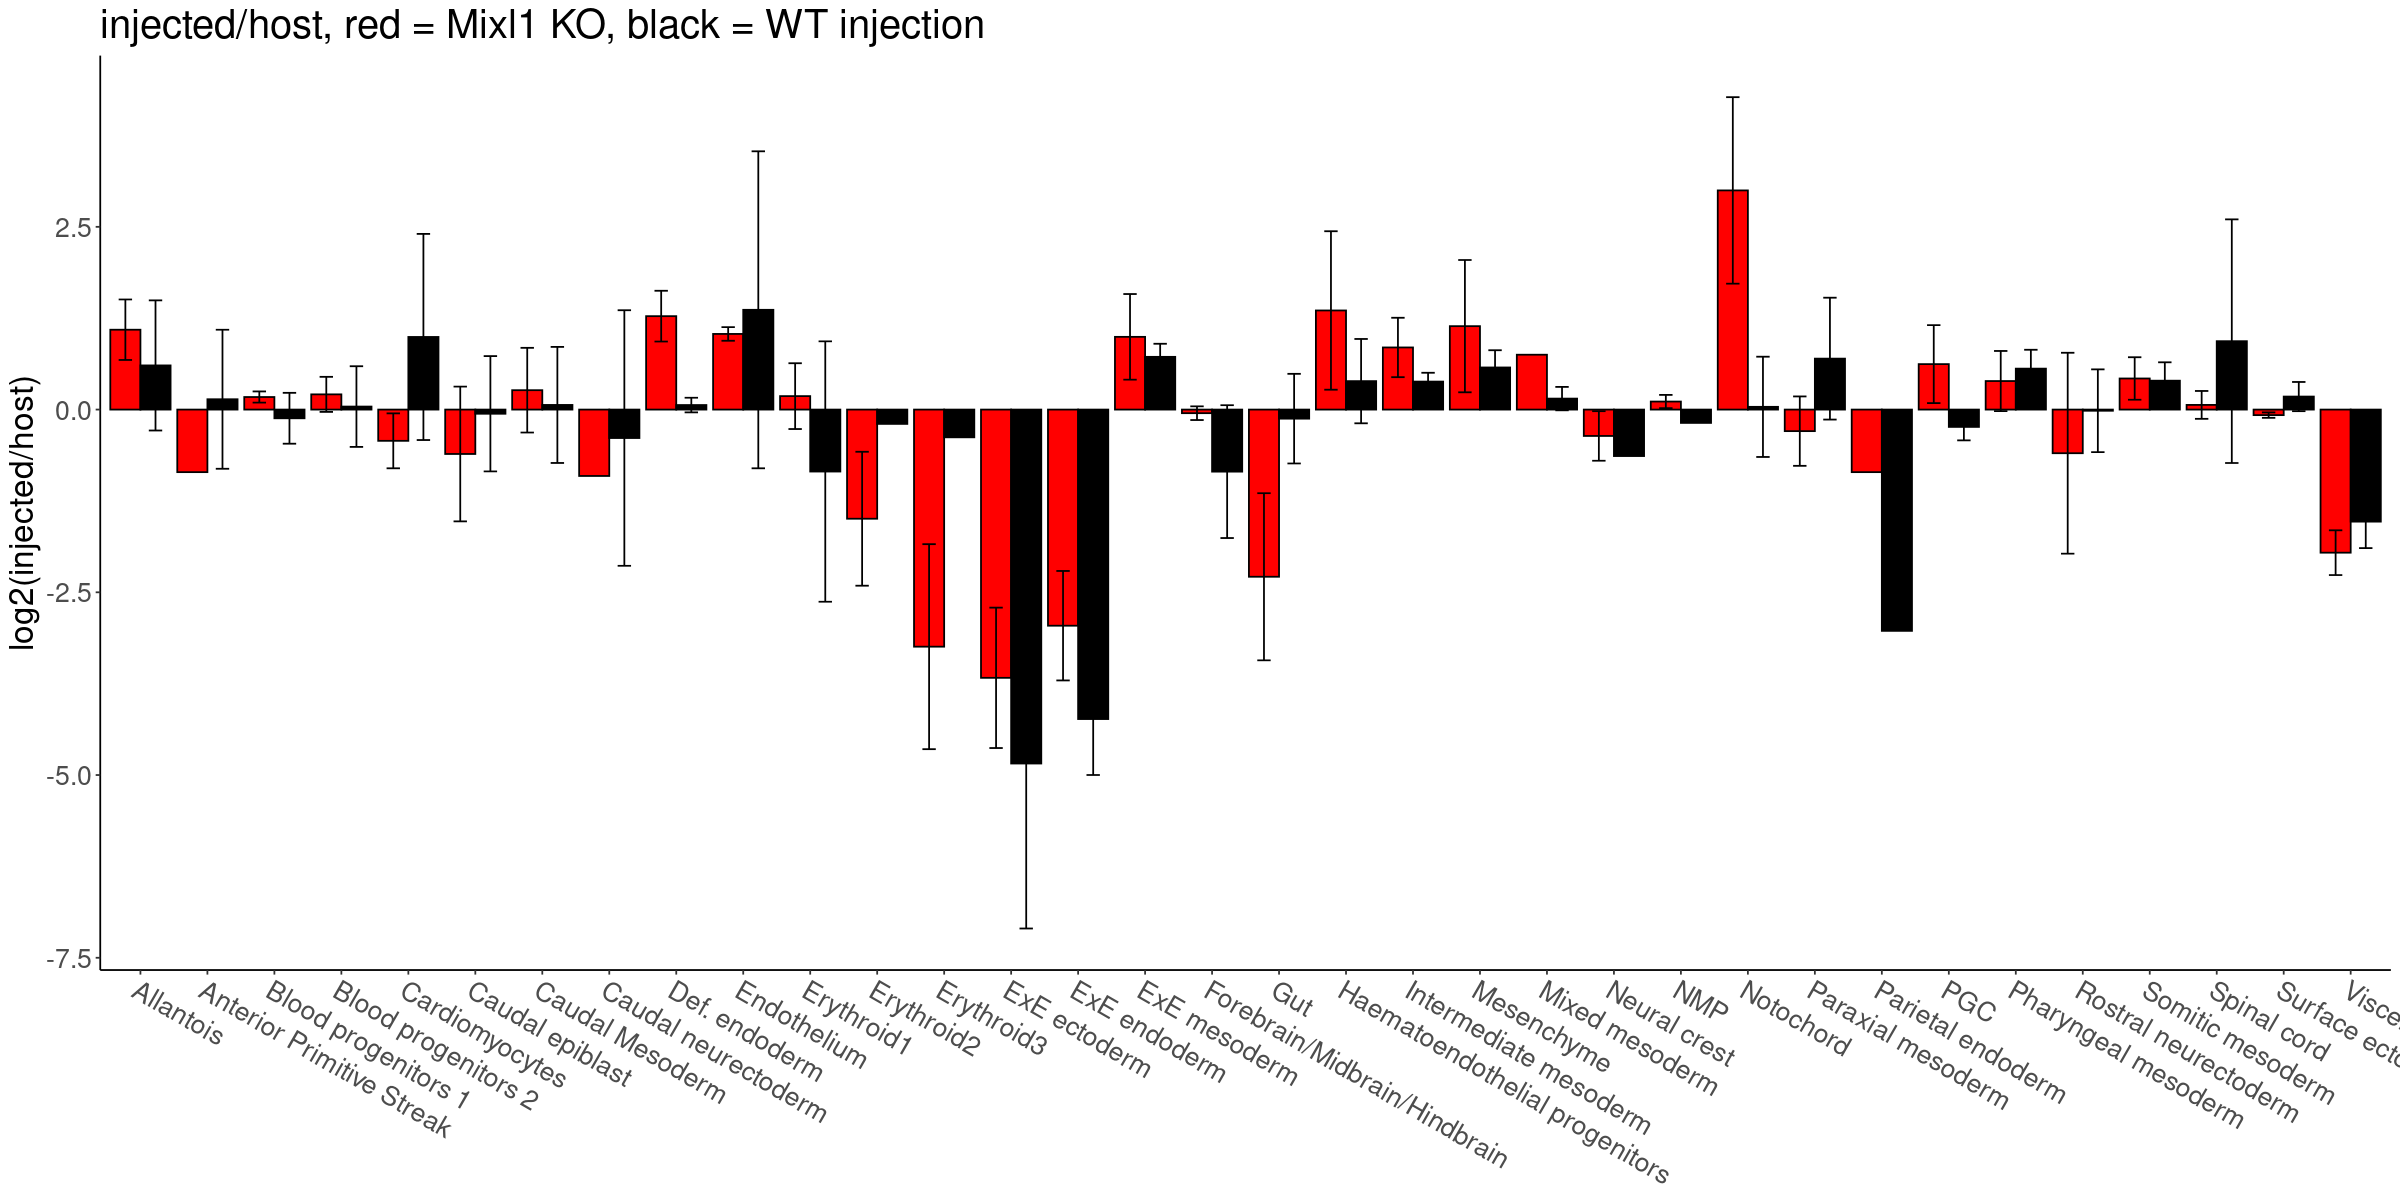

In [339]:
ggplot(data = merged3, mapping = aes(x = Var1, y = mean, fill=experiment)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("injected/host, red = Mixl1 KO, black = WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
   scale_fill_manual(values = c("KO" = "red", "WT" = "black")) +
#  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

## Propagate error when dividing injection/host

In [140]:
embryo1 <- c('1', '2') # not actually embryo but KO cell line pool
embryo2 <- c('3', '4')
embryo3 <- c('5', '6')

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tomato[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Freq = pdf1$Freq + 0.0001

pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tomato[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf1$Freq = pdf1$Freq + 0.0001

pdf4 = table(meta$celltype.mapped[meta$sample %in% embryo3], meta$tomato[meta$sample %in% embryo3])
pdf4 = as.data.frame(sweep(pdf4, 2, colSums(pdf4), "/"))
pdf4$Freq = pdf4$Freq + 0.0001

pdf3 = table(meta$celltype.mapped, meta$tomato)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.0001


colnames(pdf1) = c('Var1','Var2', 'Freq_1')
colnames(pdf2) = c('Var1','Var2', 'Freq_2')
colnames(pdf3) = c('Var1','Var2', 'Freq_3')
merged = merge(pdf1, pdf2, by=c('Var1', 'Var2'), all=TRUE)
merged = merge(merged, pdf3, by=c('Var1', 'Var2'), all=TRUE)

merged2 = gather(merged, sample, frequency, Freq_1:Freq_3)

merged2 = merged2 %>% group_by(Var1, Var2) %>% summarize(mean = mean(frequency, na.rm=TRUE), sd = sd(frequency, na.rm=TRUE))

merged2$Var1 = factor(merged2$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])  

p4 = ggplot(data = merged2, mapping = aes(x = Var1, y = mean, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)



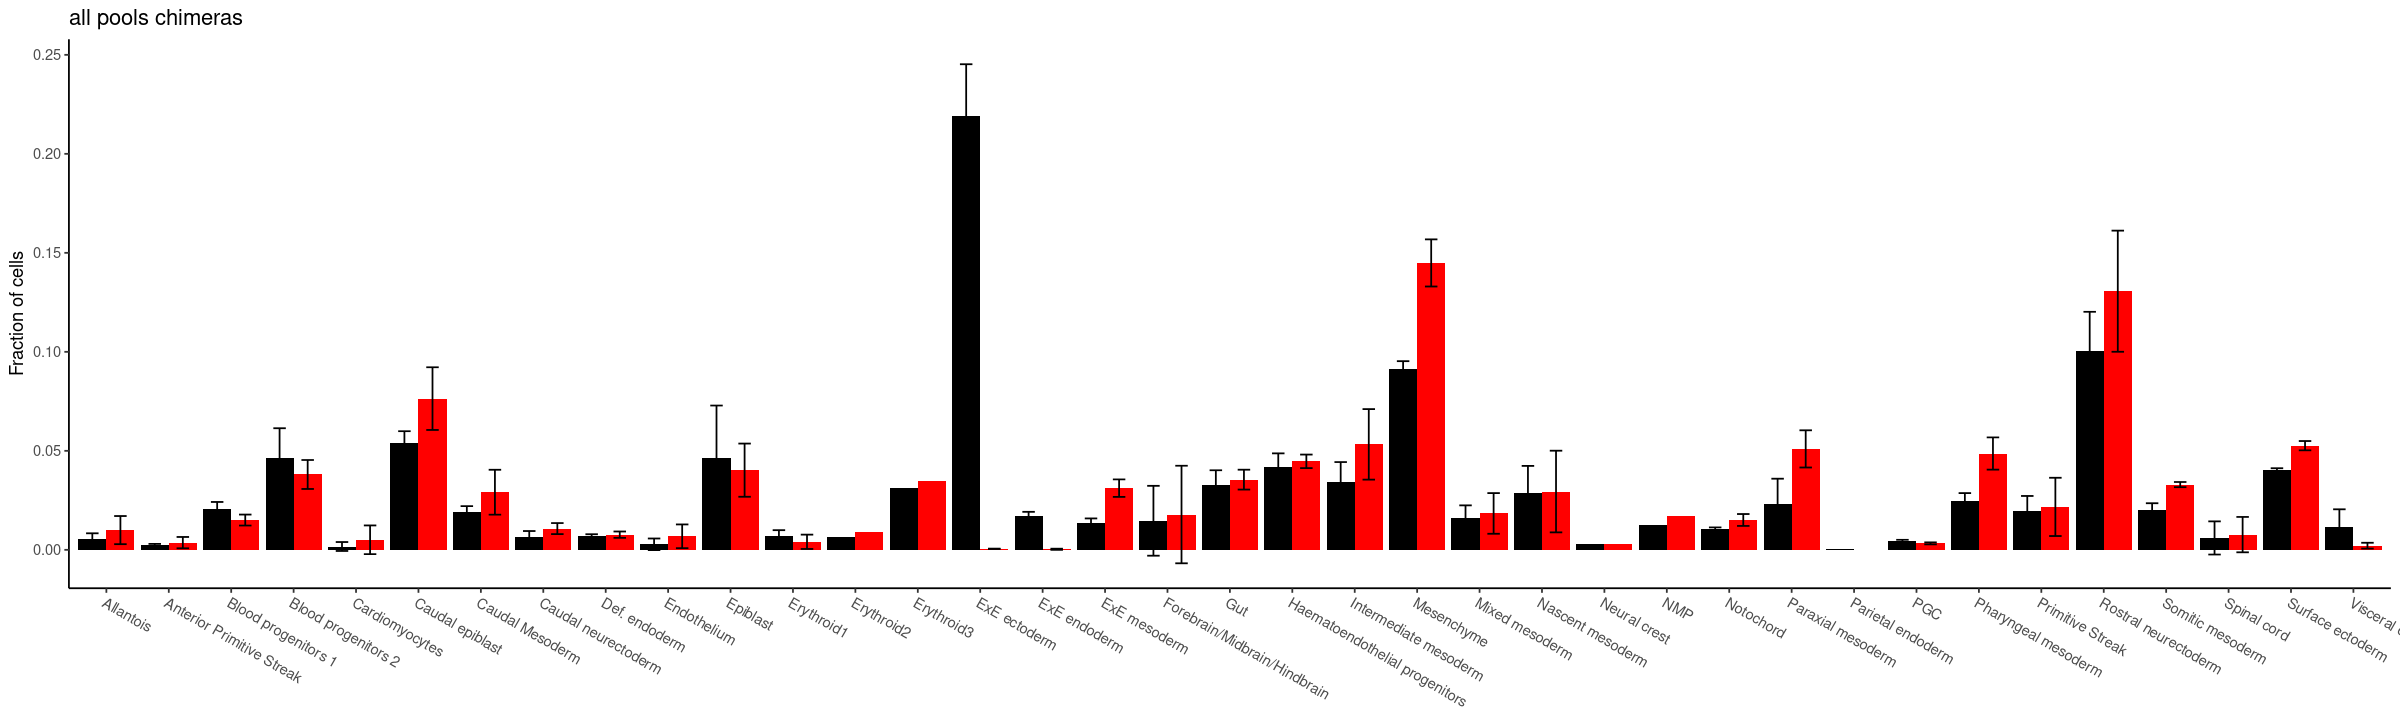

In [141]:
options(repr.plot.width = 20, repr.plot.height = 6)
p4

In [142]:
# propagating error when calculating injected/host
means = merged2 %>% select(Var1, Var2, mean)
ratio_mean = spread(means, Var2, mean)
colnames(ratio_mean) = c('Var1', 'host', 'inject')
ratio_mean$ratio = log(ratio_mean$inject / ratio_mean$host)
ratio_mean_bu = ratio_mean
ratio_mean = ratio_mean %>% select(Var1, ratio)

error = merged2 %>% select(Var1, Var2, sd)
ratio_error = spread(error, Var2, sd)
colnames(ratio_error) = c('Var1', 'host', 'inject')
ratio_error$sd = ratio_mean_bu$ratio*sqrt((ratio_error$inject/ratio_mean_bu$inject)^2 + (ratio_error$host/ratio_mean_bu$host)^2)
#ratio_error$sd = log(ratio_error$inject / ratio_error$host)
ratio_error = ratio_error %>% select(Var1, sd)

merged3 = merge(ratio_mean, ratio_error, by='Var1')

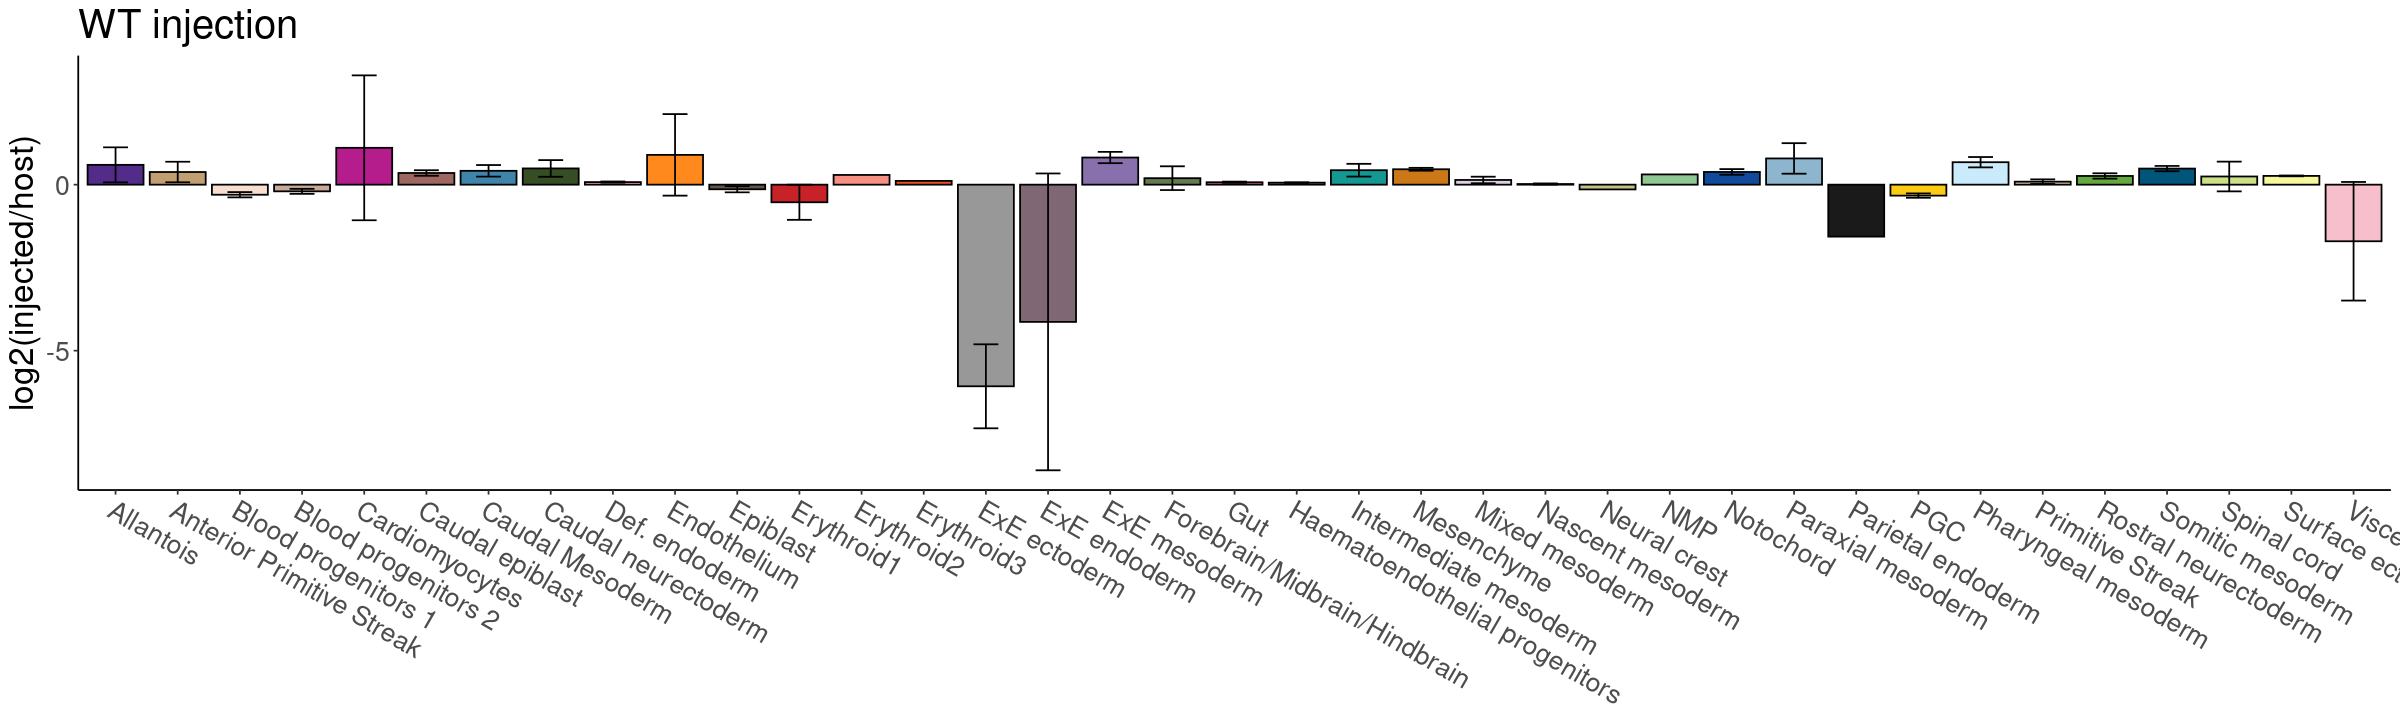

In [143]:
ggplot(data = merged3, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("WT injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [144]:
wt_final = merged3

In [145]:
embryo1 <- c('mixl_1','mixl_2') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_3','mixl_4')
embryo3 <- c('mixl_6','mixl_5')

pdf1 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo1], own_meta$tdTom[own_meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Freq = pdf1$Freq + 0.0001

pdf2 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo2], own_meta$tdTom[own_meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf2$Freq = pdf2$Freq + 0.0001


pdf3 = table(own_meta$celltype.mapped[own_meta$sample %in% embryo3], own_meta$tdTom[own_meta$sample %in% embryo3])
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))
pdf3$Freq = pdf3$Freq + 0.0001


colnames(pdf1) = c('Var1','Var2', 'Freq_1')
colnames(pdf2) = c('Var1','Var2', 'Freq_2')
colnames(pdf3) = c('Var1','Var2', 'Freq_3')
merged = merge(pdf1, pdf2, by=c('Var1', 'Var2'), all=TRUE)
merged = merge(merged, pdf3, by=c('Var1', 'Var2'), all=TRUE)

merged2 = gather(merged, sample, frequency, Freq_1:Freq_3)

merged2 = merged2 %>% group_by(Var1, Var2) %>% summarize(mean = mean(frequency, na.rm=TRUE), sd = sd(frequency, na.rm=TRUE))

merged2$Var1 = factor(merged2$Var1,levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])  

p4 <- ggplot(data = merged2, mapping = aes(x = Var1, y = mean, fill=Var2)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO chimaera") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
   scale_fill_manual(values = c("pos" = "red", "neg" = "black")) +
#  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)



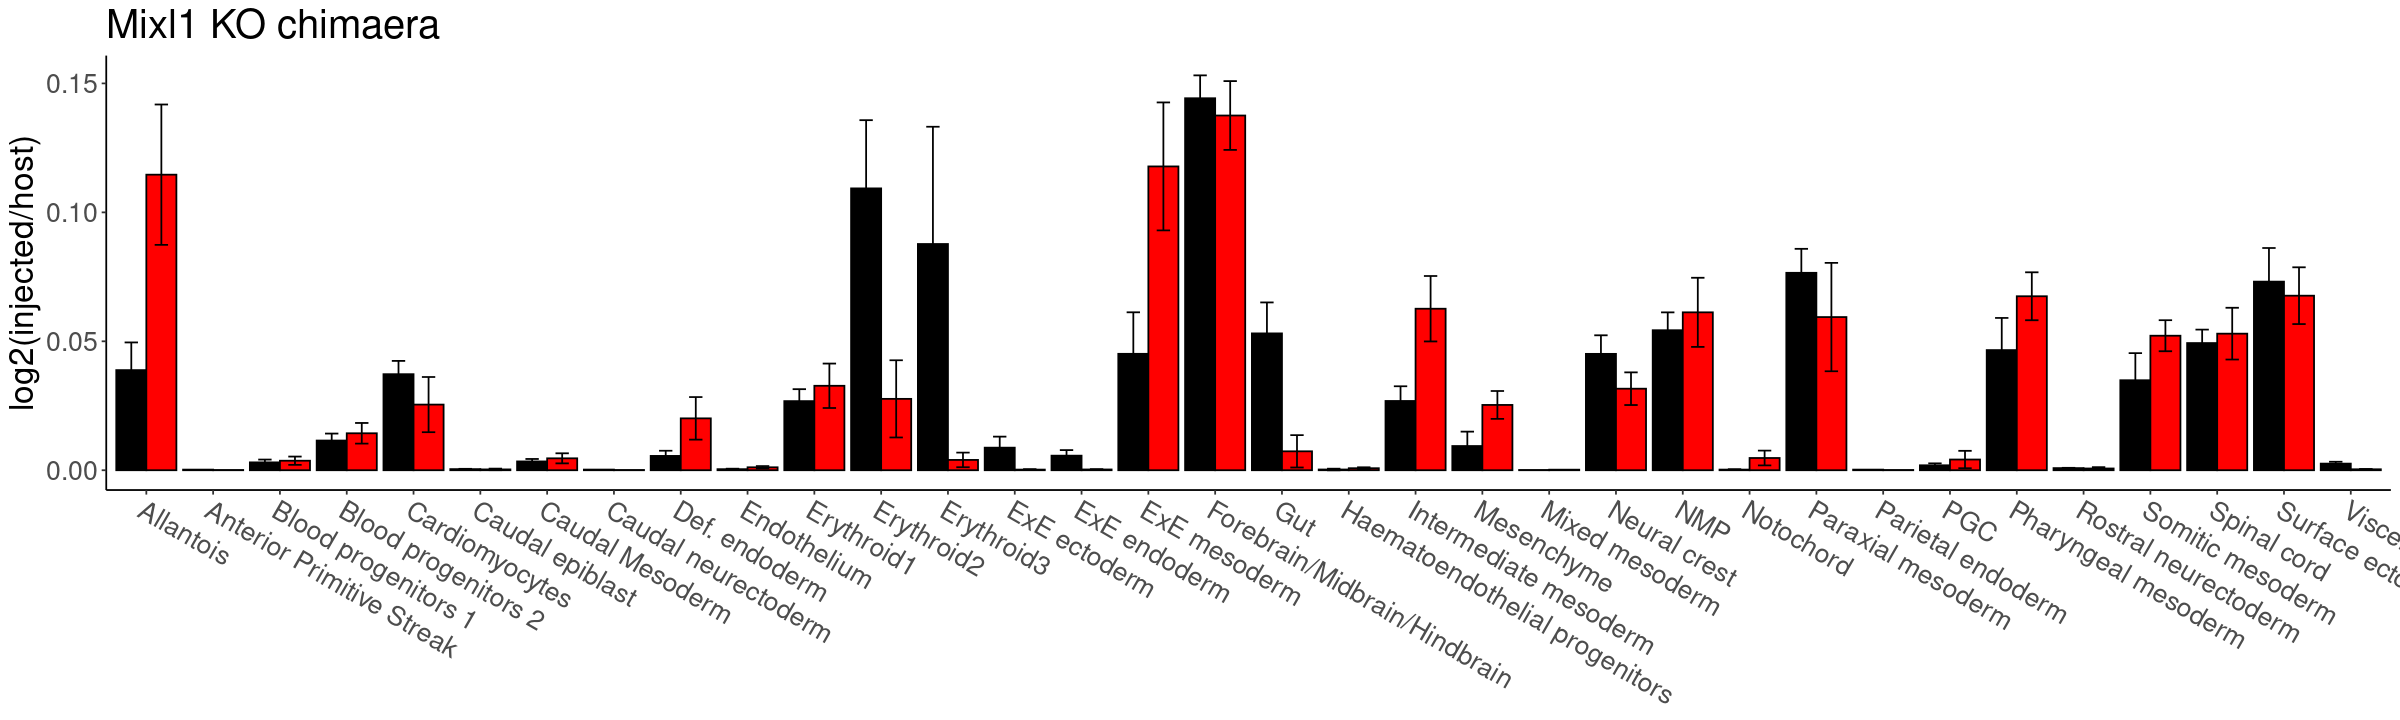

In [146]:
options(repr.plot.width = 20, repr.plot.height = 6)
p4

In [149]:
# propagating error when calculating injected/host
means = merged2 %>% select(Var1, Var2, mean)
ratio_mean = spread(means, Var2, mean)
colnames(ratio_mean) = c('Var1', 'host', 'inject')
ratio_mean$ratio = log(ratio_mean$inject / ratio_mean$host)
ratio_mean_bu = ratio_mean
ratio_mean = ratio_mean %>% select(Var1, ratio)

error = merged2 %>% select(Var1, Var2, sd)
ratio_error = spread(error, Var2, sd)
colnames(ratio_error) = c('Var1', 'host', 'inject')
ratio_error$sd = ratio_mean_bu$ratio*sqrt((ratio_error$inject/ratio_mean_bu$inject)^2 + (ratio_error$host/ratio_mean_bu$host)^2)
#ratio_error$sd = log(ratio_error$inject / ratio_error$host)
ratio_error = ratio_error %>% select(Var1, sd)

merged3 = merge(ratio_mean, ratio_error, by='Var1')

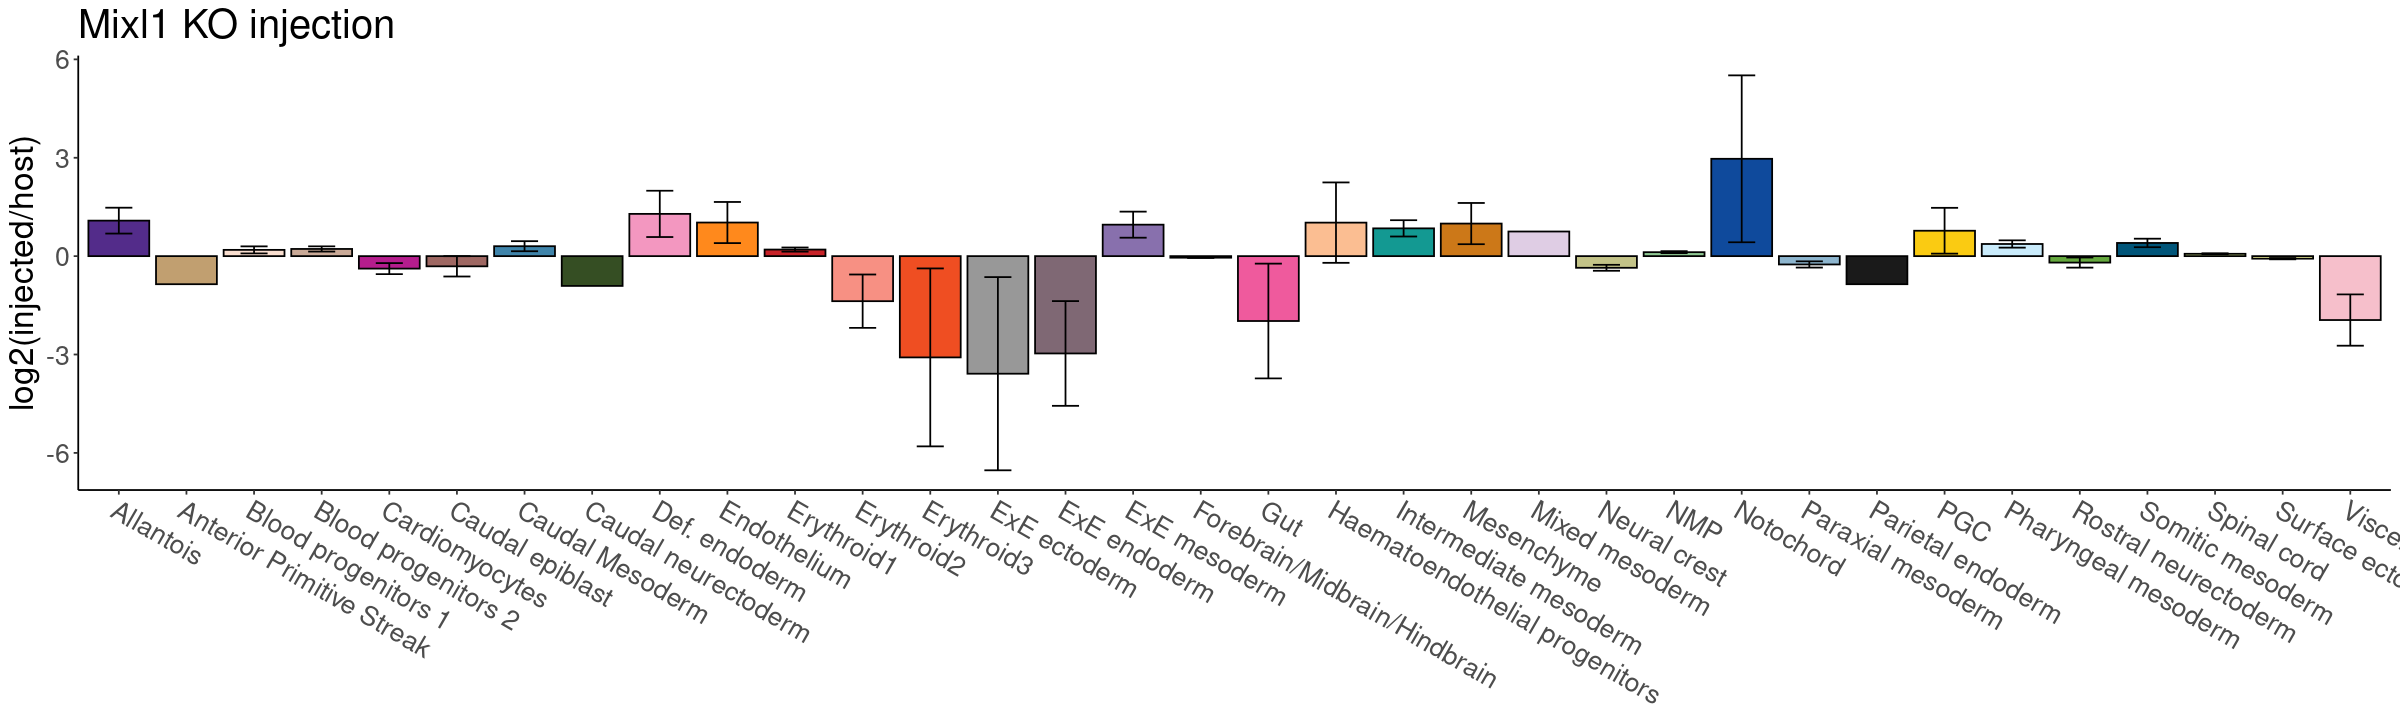

In [150]:
ggplot(data = merged3, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [151]:
ko_final = merged3

In [152]:
colnames(wt_final) = c('Var1', 'mean_wt', 'sd_wt')
colnames(ko_final) = c('Var1', 'mean_ko', 'sd_ko')
merged2 = merge(wt_final, ko_final, by='Var1')
merged2$ratio = merged2$mean_ko/merged2$mean_wt
merged2$sd = merged2$ratio*sqrt((merged2$sd_ko/merged2$mean_ko)^2 + (merged2$sd_wt/merged2$mean_wt)^2)

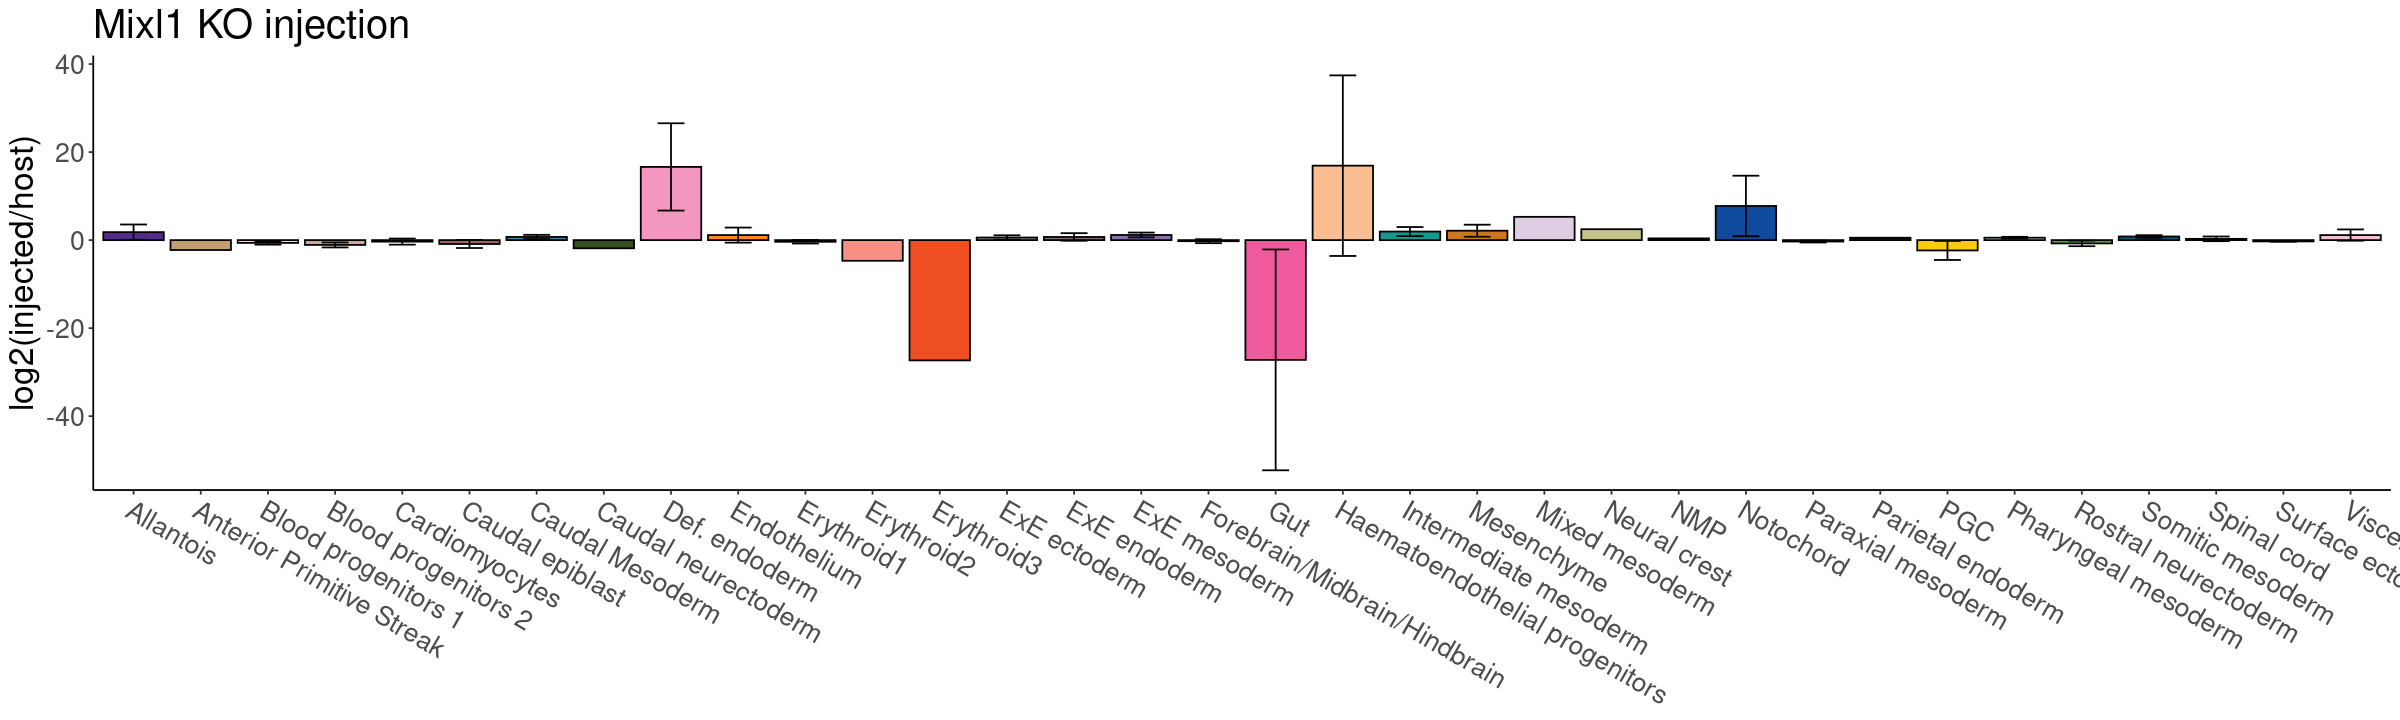

In [155]:
ggplot(data = merged2, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
  geom_bar(stat = "identity", position = "dodge", color='black') +
  labs(x = "Atlas celltype", y = "log2(injected/host)") +
  ggtitle("Mixl1 KO injection") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none", text = element_text(size = 20), 
        axis.title.x = element_blank()) +
   geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

In [2]:
head(wt)

ERROR: Error in head(wt): object 'wt' not found
